# 🍽️ Restaurant Complaint Classification
## Custom Transformer from Scratch — Production-Grade ML Pipeline

**Dataset:** `restaurant_complaints_final.csv`  
**Target:** `complaint_label` (6 classes)  
**Model:** Custom Transformer (PyTorch only — no HuggingFace, no pretrained models)

---
**Pipeline Overview:**
1. Data Inspection
2. Data Validation
3. Exploratory Data Analysis
4. Data Leakage Detection
5. Text Preprocessing
6. Feature Engineering Analysis
7. Label Encoding
8. Train / Validation / Test Split
9. Traditional NLP Baselines
10. Cross Validation
11. Custom Transformer Architecture
12. Vocabulary Creation
13. Training Configuration
14. Device Optimization
15. Training Visualization
16. Model Evaluation
17. Model Comparison
18. Error Analysis
19. Model Saving
20. Inference Functions
21. Deployment Preparation

## 📦 Global Imports & Setup

In [ ]:
# ─── Standard Library ────────────────────────────────────────────────────────
import os
import re
import json
import math
import pickle
import warnings
import unicodedata
from collections import Counter, defaultdict
from typing import Dict, List, Tuple, Optional

# ─── Data / Numeric ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from wordcloud import WordCloud

# ─── Scikit-learn ────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

# ─── PyTorch ─────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_rows', 20)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print('✅ All imports successful.')
print(f'   PyTorch version : {torch.__version__}')
print(f'   Pandas  version : {pd.__version__}')
print(f'   NumPy   version : {np.__version__}')

✅ All imports successful.
   PyTorch version : 2.2.2
   Pandas  version : 2.2.2
   NumPy   version : 1.26.4


---
## Phase 1 — Data Inspection 🔍

In [2]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
DATA_PATH = '/Users/sakshamchauhan/Desktop/GenAI-Restaurant-Review/Datasets/Complaints.csv'
df_raw = pd.read_csv(DATA_PATH)

print('=' * 65)
print('  DATASET INSPECTION REPORT')
print('=' * 65)

# Shape
print(f'\n📐 Shape            : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')

# Columns
print(f'\n📋 Columns          : {list(df_raw.columns)}')

# Data Types
print('\n🔢 Data Types:')
print(df_raw.dtypes.to_string())

# Missing Values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('\n❓ Missing Values:')
print(missing_df.to_string())

# Duplicate Rows
dup_rows = df_raw.duplicated().sum()
print(f'\n🔁 Duplicate Rows   : {dup_rows}')

# Duplicate Reviews
dup_reviews = df_raw['review_text'].duplicated().sum()
print(f'🔁 Duplicate Reviews: {dup_reviews}')

# Unique Labels
unique_labels = df_raw['complaint_label'].unique()
print(f'\n🏷️  Unique Labels ({len(unique_labels)}):')
for lbl in sorted(unique_labels):
    print(f'   • {lbl}')

# Class Distribution
class_dist = df_raw['complaint_label'].value_counts()
class_pct  = (class_dist / len(df_raw) * 100).round(2)
class_df   = pd.DataFrame({'Count': class_dist, 'Percentage %': class_pct})
print('\n📊 Class Distribution:')
print(class_df.to_string())

# Sample Records
print('\n📄 Sample Records (5):')
display(df_raw.sample(5, random_state=RANDOM_SEED))

# Memory Usage
mem_bytes = df_raw.memory_usage(deep=True).sum()
print(f'\n💾 Memory Usage     : {mem_bytes / 1024:.1f} KB  ({mem_bytes:,} bytes)')
print('\n' + '=' * 65)

  DATASET INSPECTION REPORT

📐 Shape            : 10,800 rows × 6 columns

📋 Columns          : ['review_id', 'review_text', 'complaint_label', 'severity_label', 'stars', 'sentiment_label']

🔢 Data Types:
review_id          object
review_text        object
complaint_label    object
severity_label     object
stars               int64
sentiment_label    object

❓ Missing Values:
                 Missing Count  Missing %
review_id                    0        0.0
review_text                  0        0.0
complaint_label              0        0.0
severity_label               0        0.0
stars                        0        0.0
sentiment_label              0        0.0

🔁 Duplicate Rows   : 0
🔁 Duplicate Reviews: 0

🏷️  Unique Labels (6):
   • Cleanliness Issue
   • Food Quality
   • General Dissatisfaction
   • Pricing Issue
   • Service Delay
   • Staff Behavior

📊 Class Distribution:
                         Count  Percentage %
complaint_label                             
General Dissat

,review_id,review_text,complaint_label,severity_label,stars,sentiment_label
1254,RC001255,"Honestly, the ramen bowl was undercooked and still pink/raw in the middle, w...",Food Quality,High,1,Negative
9033,RC009034,"Overall, a fairly middle-of-the-road visit, some things were good and others...",General Dissatisfaction,Low,3,Neutral
2523,RC002524,"The delivery from the food delivery app arrived earlier than expected, which...",Service Delay,Low,5,Positive
10670,RC010671,I specifically asked for no onions in my cheesecake but they added them anyw...,Food Quality,Critical,1,Negative
8637,RC008638,The card machine at the hotel wasn't working properly the whole evening.,Pricing Issue,Medium,3,Neutral



💾 Memory Usage     : 5516.4 KB  (5,648,756 bytes)



---
## Phase 2 — Data Validation ✅

In [3]:
VALID_LABELS = {
    'Food Quality', 'Service Delay', 'Staff Behavior',
    'Pricing Issue', 'Cleanliness Issue', 'General Dissatisfaction'
}

df = df_raw.copy()

issues = {}

# 1. Null Values
null_mask = df['review_text'].isnull() | df['complaint_label'].isnull()
issues['Null Values']       = int(null_mask.sum())

# 2. Empty Reviews
empty_mask = df['review_text'].fillna('').str.strip().eq('')
issues['Empty Reviews']     = int(empty_mask.sum())

# 3. Duplicate Reviews
dup_rev_mask = df.duplicated(subset=['review_text'], keep=False)
issues['Duplicate Reviews'] = int(df['review_text'].duplicated().sum())

# 4. Duplicate Rows
issues['Duplicate Rows']    = int(df.duplicated().sum())

# 5. Invalid Labels
invalid_lbl_mask = ~df['complaint_label'].isin(VALID_LABELS)
issues['Invalid Labels']    = int(invalid_lbl_mask.sum())

# 6. Very Short Reviews (< 10 chars)
short_mask = df['review_text'].fillna('').str.len() < 10
issues['Very Short Reviews (< 10 chars)'] = int(short_mask.sum())

# 7. Very Long Reviews (> 2000 chars)
long_mask = df['review_text'].fillna('').str.len() > 2000
issues['Very Long Reviews (> 2000 chars)'] = int(long_mask.sum())

# 8. Class Imbalance (ratio max/min)
dist = df['complaint_label'].value_counts()
imbalance_ratio = round(dist.max() / dist.min(), 2)
issues['Class Imbalance Ratio (max/min)'] = imbalance_ratio

print('=' * 60)
print('  DATA VALIDATION SUMMARY')
print('=' * 60)
for k, v in issues.items():
    status = '✅' if v == 0 else ('⚠️ ' if isinstance(v, float) and v < 3 else '❌')
    if k == 'Class Imbalance Ratio (max/min)':
        status = '✅' if v < 1.5 else '⚠️ '
    print(f'  {status} {k:<40}: {v}')

print('\n🧹 Removing duplicates and nulls from working copy...')
df.drop_duplicates(inplace=True)
df.dropna(subset=['review_text', 'complaint_label'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'   Cleaned dataset size: {len(df):,} rows')
print('=' * 60)

  DATA VALIDATION SUMMARY
  ✅ Null Values                             : 0
  ✅ Empty Reviews                           : 0
  ✅ Duplicate Reviews                       : 0
  ✅ Duplicate Rows                          : 0
  ✅ Invalid Labels                          : 0
  ✅ Very Short Reviews (< 10 chars)         : 0
  ✅ Very Long Reviews (> 2000 chars)        : 0
  ✅ Class Imbalance Ratio (max/min)         : 1.0

🧹 Removing duplicates and nulls from working copy...
   Cleaned dataset size: 10,800 rows


---
## Phase 3 — Exploratory Data Analysis 📈

In [4]:
# ── Compute text feature columns for EDA ─────────────────────────────────────
df['review_length']     = df['review_text'].str.len()
df['word_count']        = df['review_text'].str.split().str.len()
df['character_count']   = df['review_text'].str.replace(' ', '', regex=False).str.len()
df['sentence_count']    = df['review_text'].str.count(r'[.!?]+')
df['avg_word_length']   = df['character_count'] / df['word_count'].replace(0, 1)

print('EDA feature columns added.')
display(df[['review_text', 'review_length', 'word_count', 'character_count',
            'sentence_count', 'avg_word_length']].head())

EDA feature columns added.


,review_text,review_length,word_count,character_count,sentence_count,avg_word_length
0,"Honestly, several things went wrong during our visit, from the wait time to ...",254,43,212,3,4.930233
1,"The water park was reasonably clean, though a couple of tables could have us...",148,26,123,2,4.730769
2,"I really wanted to like this place, but the ice cream sundae had ingredients...",346,57,290,4,5.087719
3,"This was my first time here, and there were way more people than the space c...",150,27,124,2,4.592593
4,"Overall it was an average experience at this dhaba, nothing stood out much e...",198,39,160,3,4.102564


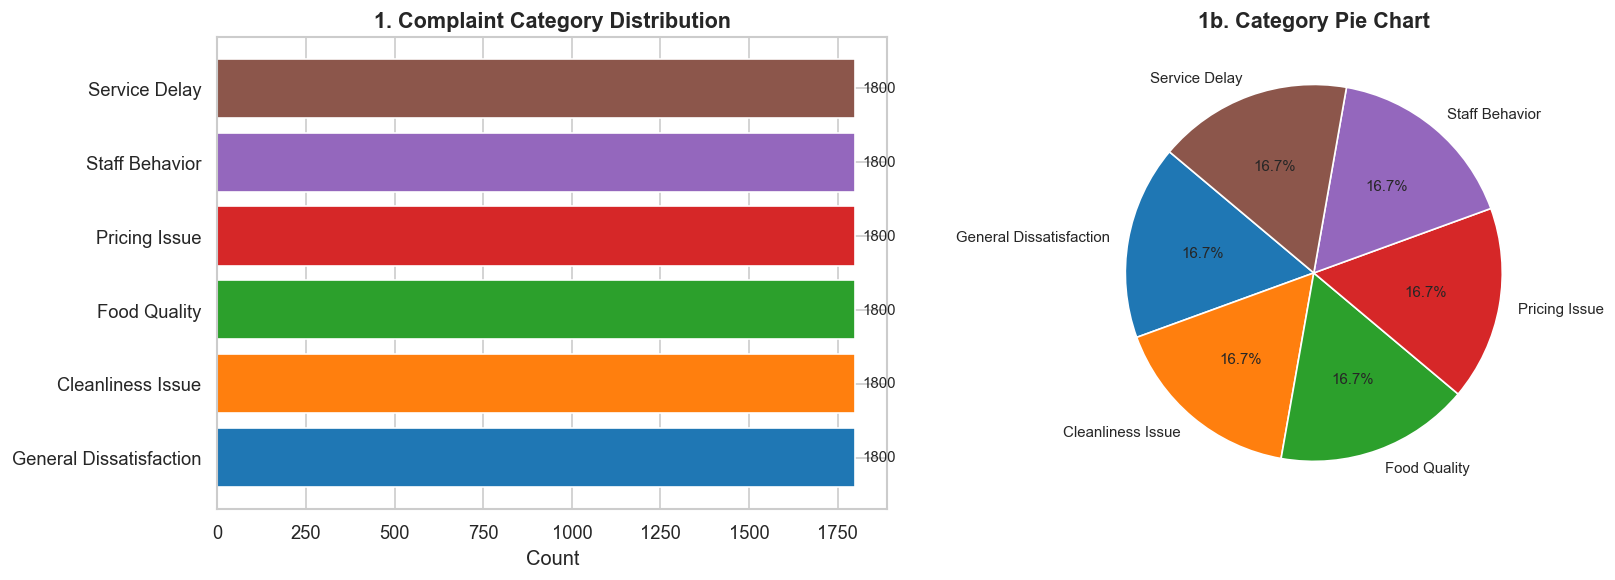

In [5]:
PALETTE = sns.color_palette('tab10', n_colors=6)
CLASSES  = sorted(df['complaint_label'].unique())

# ── 1. Complaint Category Distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df['complaint_label'].value_counts()
axes[0].barh(counts.index, counts.values, color=PALETTE)
axes[0].set_title('1. Complaint Category Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(v + 20, i, str(v), va='center', fontsize=9)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=PALETTE, startangle=140, textprops={'fontsize': 9})
axes[1].set_title('1b. Category Pie Chart', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_01_category_distribution.png', bbox_inches='tight')
plt.show()

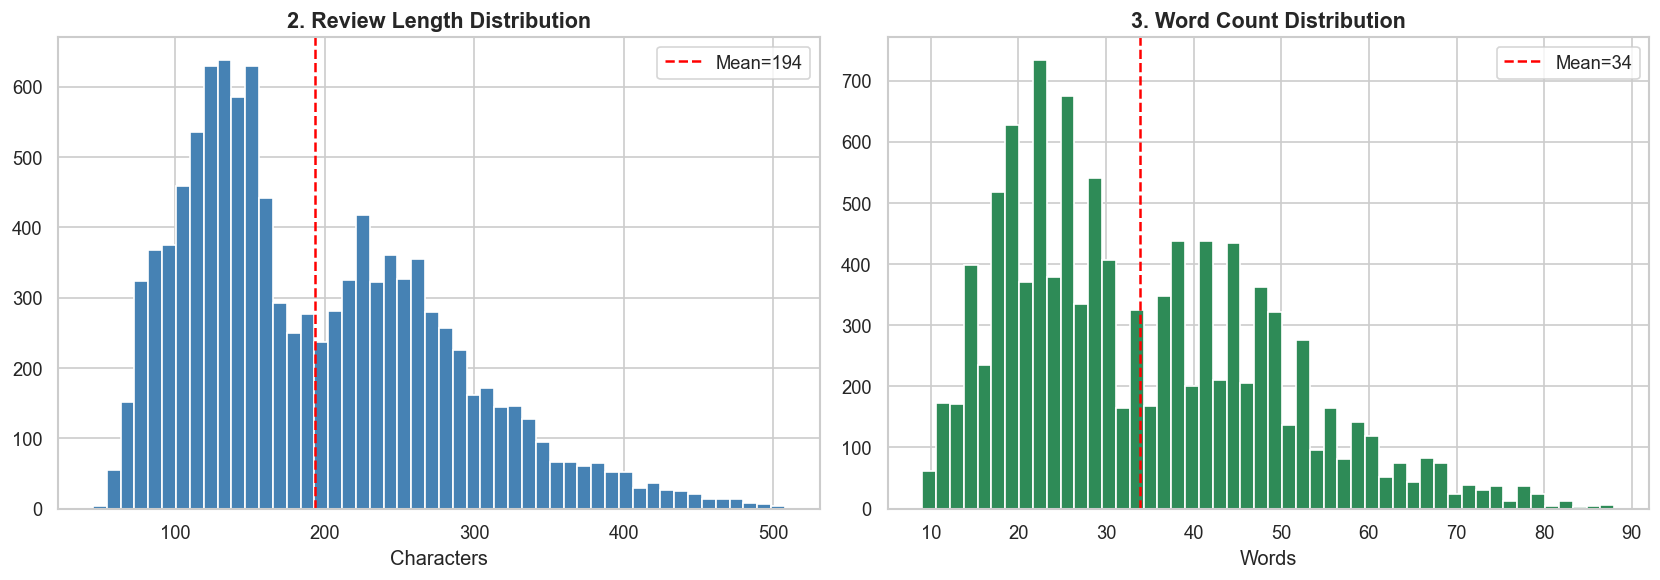

In [6]:
# ── 2. Review Length Distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['review_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['review_length'].mean(), color='red', linestyle='--', label=f'Mean={df["review_length"].mean():.0f}')
axes[0].set_title('2. Review Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Characters')
axes[0].legend()

# ── 3. Word Count Distribution ───────────────────────────────────────────────
axes[1].hist(df['word_count'], bins=50, color='seagreen', edgecolor='white')
axes[1].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Mean={df["word_count"].mean():.0f}')
axes[1].set_title('3. Word Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Words')
axes[1].legend()
plt.tight_layout()
plt.savefig('plot_02_length_word_dist.png', bbox_inches='tight')
plt.show()

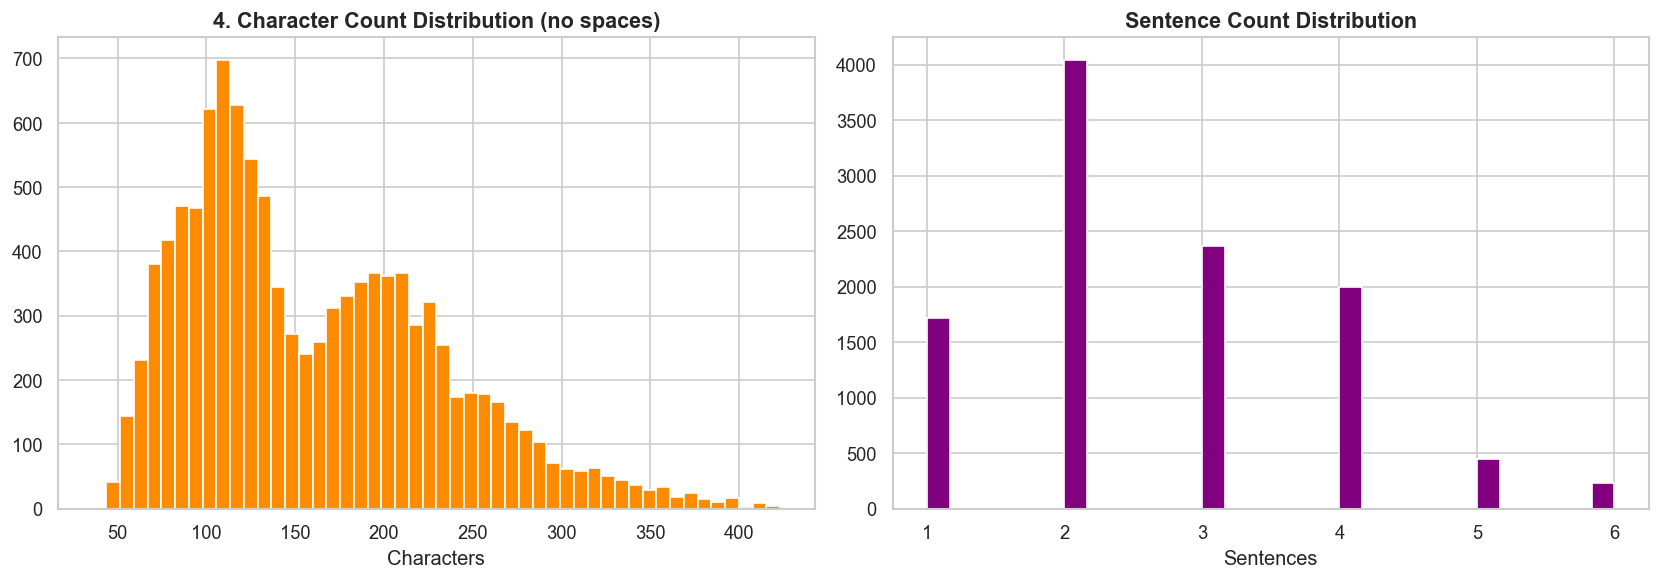

In [7]:
# ── 4. Character Count & Sentence Count Distributions ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['character_count'], bins=50, color='darkorange', edgecolor='white')
axes[0].set_title('4. Character Count Distribution (no spaces)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Characters')

axes[1].hist(df['sentence_count'], bins=30, color='purple', edgecolor='white')
axes[1].set_title('Sentence Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentences')
plt.tight_layout()
plt.savefig('plot_03_char_sentence_dist.png', bbox_inches='tight')
plt.show()

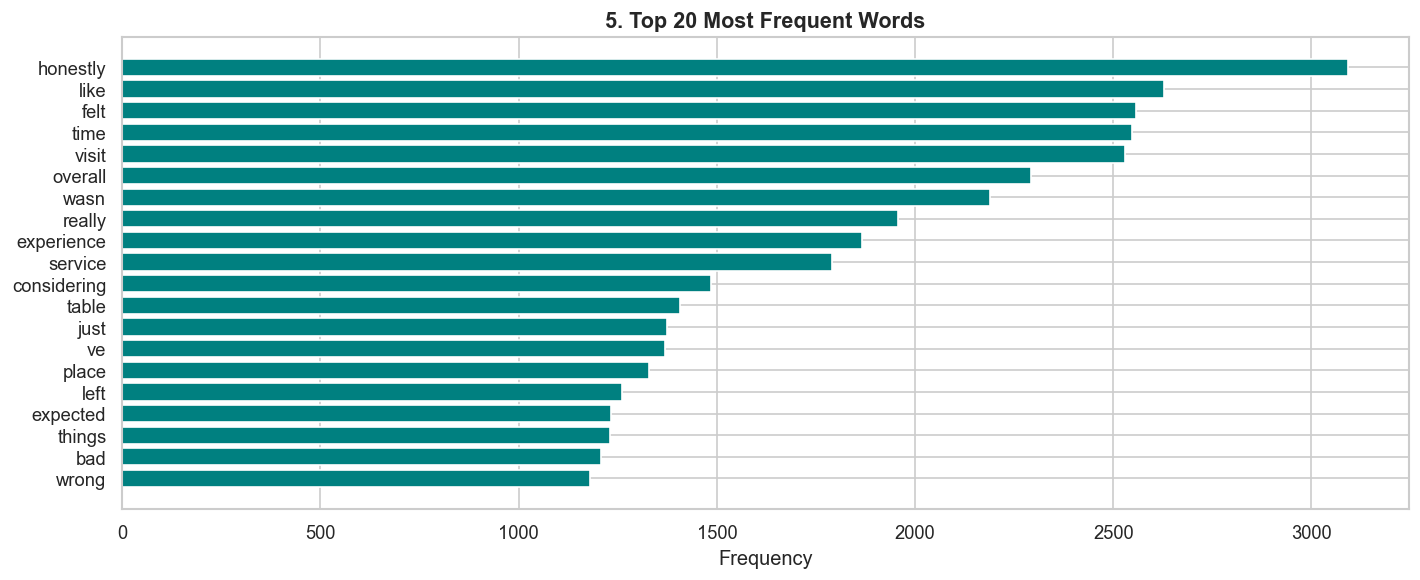

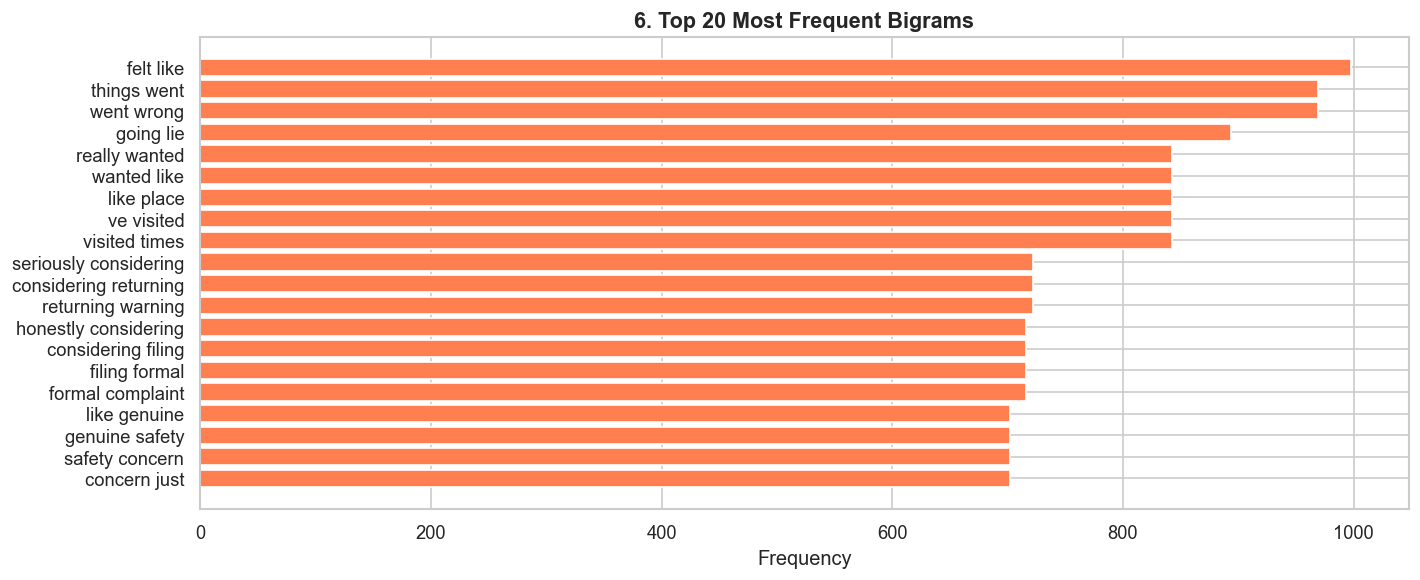

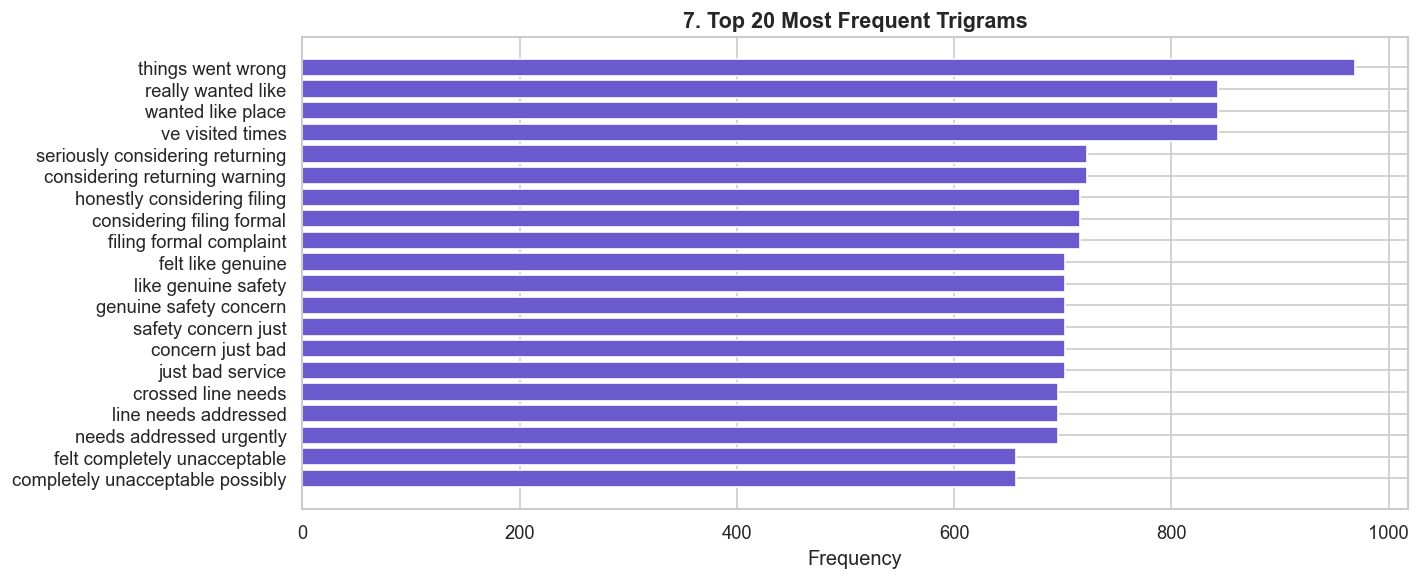

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=1, top_k=20):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=10000)
    bow = vec.fit_transform(corpus)
    freq = bow.sum(axis=0)
    words = [(word, freq[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words, key=lambda x: x[1], reverse=True)[:top_k]

corpus = df['review_text'].tolist()

# ── 5. Most Frequent Words ────────────────────────────────────────────────────
top_words = get_top_ngrams(corpus, n=1)
words, freqs = zip(*top_words)
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(words, freqs, color='teal')
ax.invert_yaxis()
ax.set_title('5. Top 20 Most Frequent Words', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('plot_04_top_words.png', bbox_inches='tight')
plt.show()

# ── 6. Most Frequent Bigrams ──────────────────────────────────────────────────
top_bigrams = get_top_ngrams(corpus, n=2)
bwords, bfreqs = zip(*top_bigrams)
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(bwords, bfreqs, color='coral')
ax.invert_yaxis()
ax.set_title('6. Top 20 Most Frequent Bigrams', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('plot_05_top_bigrams.png', bbox_inches='tight')
plt.show()

# ── 7. Most Frequent Trigrams ─────────────────────────────────────────────────
top_trigrams = get_top_ngrams(corpus, n=3)
twords, tfreqs = zip(*top_trigrams)
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(twords, tfreqs, color='slateblue')
ax.invert_yaxis()
ax.set_title('7. Top 20 Most Frequent Trigrams', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('plot_06_top_trigrams.png', bbox_inches='tight')
plt.show()

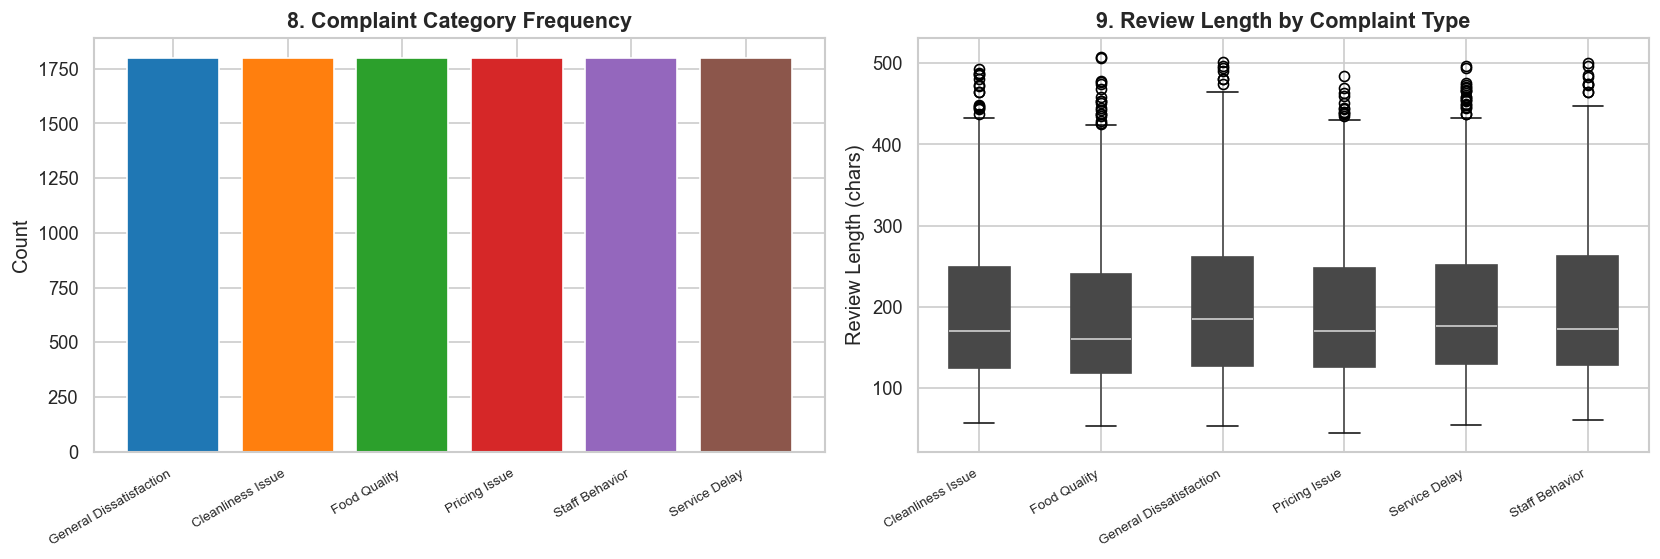

In [9]:
# ── 8 & 9. Complaint Category Frequency & Review Length by Category ───────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 8
cat_freq = df['complaint_label'].value_counts()
axes[0].bar(cat_freq.index, cat_freq.values, color=PALETTE)
axes[0].set_title('8. Complaint Category Frequency', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(cat_freq.index, rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('Count')

# 9
df.boxplot(column='review_length', by='complaint_label', ax=axes[1],
           patch_artist=True, vert=True)
axes[1].set_title('9. Review Length by Complaint Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Review Length (chars)')
plt.suptitle('')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('plot_07_freq_length_by_cat.png', bbox_inches='tight')
plt.show()

In [10]:
# ── 10. Text Statistics ───────────────────────────────────────────────────────
stats = df[['review_length', 'word_count', 'character_count',
            'sentence_count', 'avg_word_length']].describe().T
print('10. Text Statistics')
display(stats.style.format('{:.2f}').background_gradient(cmap='Blues', axis=1))

# ── 11. Class Balance Analysis ────────────────────────────────────────────────
print('\n11. Class Balance Analysis')
dist = df['complaint_label'].value_counts()
balance_df = pd.DataFrame({
    'Count': dist,
    'Pct': (dist / dist.sum() * 100).round(2),
    'Ratio to Max': (dist / dist.max()).round(3)
})
display(balance_df)
print(f'Imbalance ratio (max/min): {dist.max()/dist.min():.2f}')

10. Text Statistics


,count,mean,std,min,25%,50%,75%,max
review_length,10800.00,193.62,86.16,45.00,126.00,171.00,252.00,508.00
word_count,10800.00,33.89,15.04,9.00,22.00,30.00,44.00,88.00
character_count,10800.00,160.73,71.34,36.00,105.00,143.00,209.00,423.00
sentence_count,10800.00,2.64,1.19,1.00,2.00,2.00,3.00,6.00
avg_word_length,10800.00,4.77,0.45,3.36,4.47,4.74,5.04,7.00



11. Class Balance Analysis


,Count,Pct,Ratio to Max
complaint_label,,,
General Dissatisfaction,1800,16.67,1.0
Cleanliness Issue,1800,16.67,1.0
Food Quality,1800,16.67,1.0
Pricing Issue,1800,16.67,1.0
Staff Behavior,1800,16.67,1.0
Service Delay,1800,16.67,1.0


Imbalance ratio (max/min): 1.00


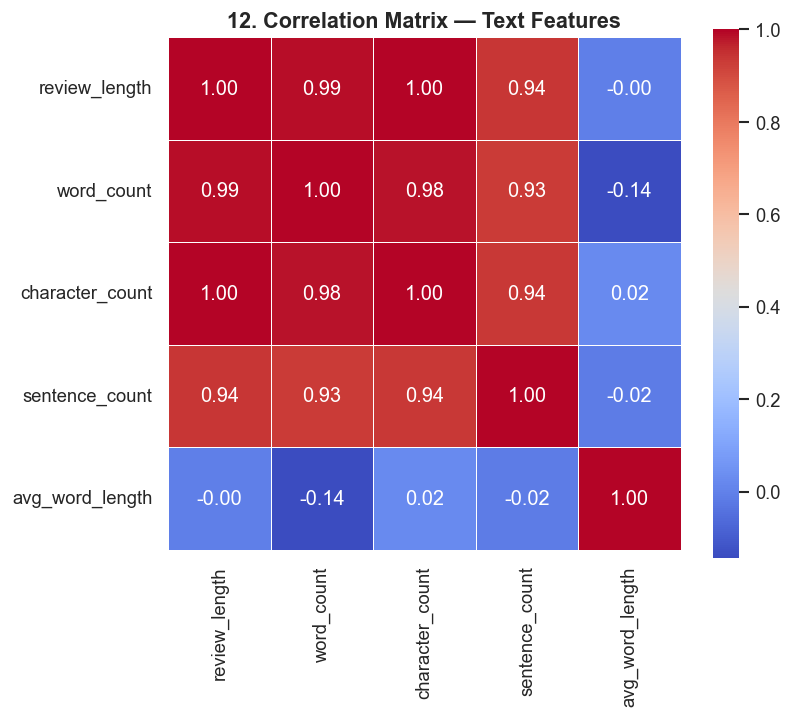

In [11]:
# ── 12. Correlation Analysis ──────────────────────────────────────────────────
numeric_cols = ['review_length', 'word_count', 'character_count', 'sentence_count', 'avg_word_length']
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            linewidths=0.5, square=True)
ax.set_title('12. Correlation Matrix — Text Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_08_correlation.png', bbox_inches='tight')
plt.show()

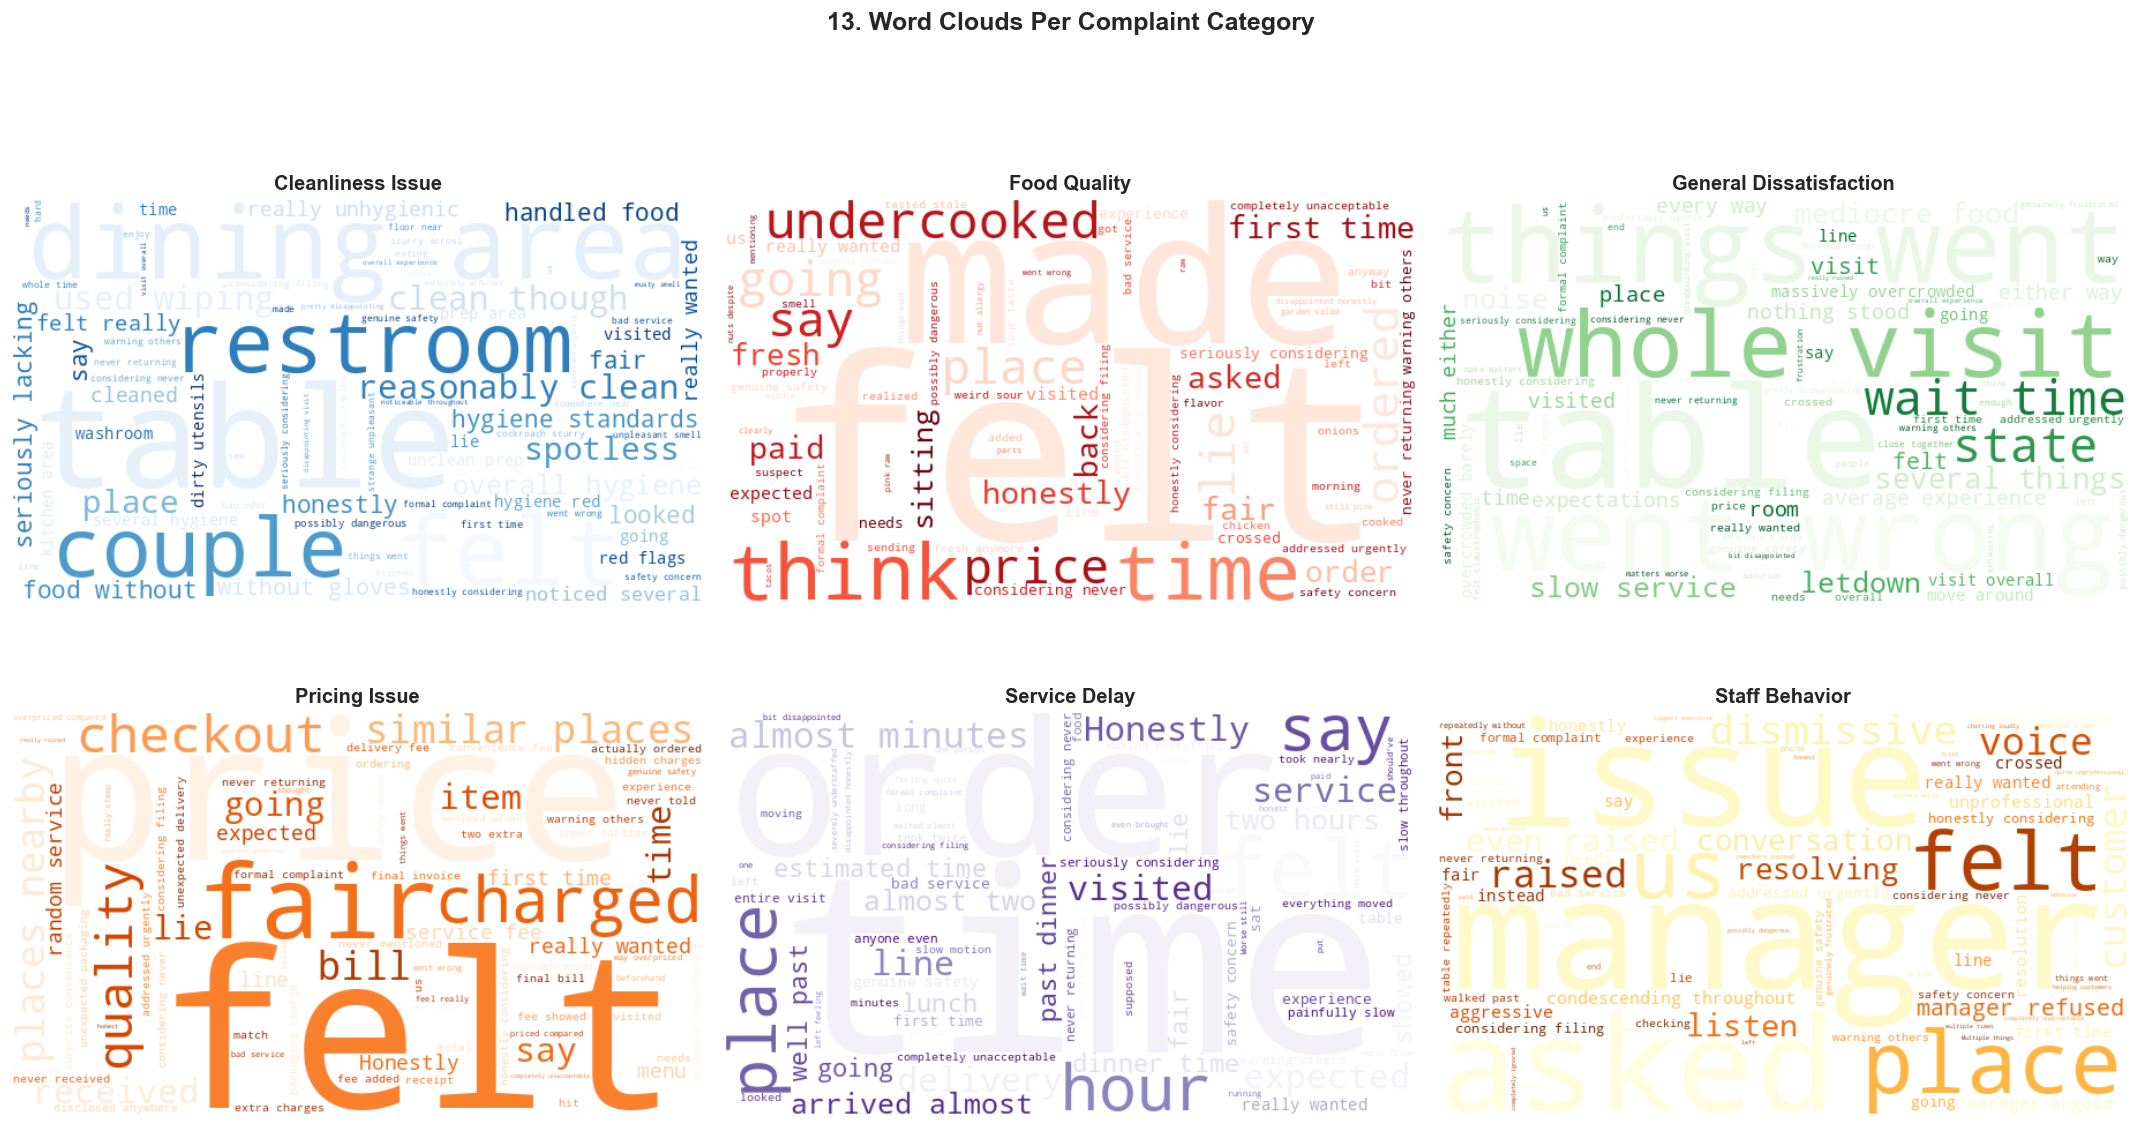

In [12]:
# ── 13. Word Clouds Per Category ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

COLORMAP_LIST = ['Blues', 'Reds', 'Greens', 'Oranges', 'Purples', 'YlOrBr']

for idx, label in enumerate(CLASSES):
    text = ' '.join(df[df['complaint_label'] == label]['review_text'].tolist())
    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap=COLORMAP_LIST[idx],
        max_words=80,
        random_state=RANDOM_SEED
    ).generate(text)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(label, fontsize=12, fontweight='bold')

plt.suptitle('13. Word Clouds Per Complaint Category', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_09_wordclouds.png', bbox_inches='tight')
plt.show()

---
## Phase 4 — Data Leakage Detection 🚨

In [13]:
from scipy.stats import chi2_contingency

SUSPECT_COLS = ['review_id', 'severity_label', 'sentiment_label', 'stars']

print('=' * 65)
print('  DATA LEAKAGE DETECTION REPORT')
print('=' * 65)

leakage_results = {}
for col in SUSPECT_COLS:
    if col not in df.columns:
        print(f'  Column "{col}" not found — skip.')
        continue

    # Cramér's V for categorical / discrete
    contingency = pd.crosstab(df[col], df['complaint_label'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    n = contingency.sum().sum()
    k = min(contingency.shape)
    cramers_v = np.sqrt(chi2 / (n * (k - 1))) if k > 1 else 0.0

    risk = 'HIGH 🔴' if cramers_v > 0.5 else ('MEDIUM 🟡' if cramers_v > 0.2 else 'LOW 🟢')
    leakage_results[col] = {'Cramér\'s V': round(cramers_v, 4), 'p-value': round(p, 6), 'Risk': risk}

    print(f'\n  Column : {col}')
    print(f'  Cramér\'s V : {cramers_v:.4f}   p-value: {p:.6f}   → {risk}')

leakage_df = pd.DataFrame(leakage_results).T
print('\n  Summary Table:')
display(leakage_df)

# Remove leakage / meta columns — keep ONLY review_text for training
COLS_TO_DROP = [c for c in SUSPECT_COLS if c in df.columns]
COLS_TO_DROP += [c for c in ['review_length', 'word_count', 'character_count',
                               'sentence_count', 'avg_word_length'] if c in df.columns]
df_model = df.drop(columns=COLS_TO_DROP).copy()

print(f'\n✅ Dropped columns: {COLS_TO_DROP}')
print(f'   Remaining columns: {list(df_model.columns)}')
print('=' * 65)

  DATA LEAKAGE DETECTION REPORT

  Column : review_id
  Cramér's V : 1.0000   p-value: 0.493121   → HIGH 🔴

  Column : severity_label
  Cramér's V : 0.0000   p-value: 1.000000   → LOW 🟢

  Column : sentiment_label
  Cramér's V : 0.0146   p-value: 0.916237   → LOW 🟢

  Column : stars
  Cramér's V : 0.0132   p-value: 0.994780   → LOW 🟢

  Summary Table:


,Cramér's V,p-value,Risk
review_id,1.0,0.493121,HIGH 🔴
severity_label,0.0,1.0,LOW 🟢
sentiment_label,0.0146,0.916237,LOW 🟢
stars,0.0132,0.99478,LOW 🟢



✅ Dropped columns: ['review_id', 'severity_label', 'sentiment_label', 'stars', 'review_length', 'word_count', 'character_count', 'sentence_count', 'avg_word_length']
   Remaining columns: ['review_text', 'complaint_label']


---
## Phase 5 — Text Preprocessing 🧹

In [14]:
def preprocess_text(text: str) -> str:
    """Production-grade text cleaner — preserves semantic meaning."""
    if not isinstance(text, str):
        return ''

    # 1. Unicode normalisation (NFC)
    text = unicodedata.normalize('NFC', text)

    # 2. Lowercase
    text = text.lower()

    # 3. Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # 4. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # 5. Remove emails
    text = re.sub(r'[\w.+-]+@[\w-]+\.[\w.]+', ' ', text)

    # 6. Expand contractions (basic common ones)
    contractions = {
        "n't": " not", "'re": " are", "'s": " is", "'d": " would",
        "'ll": " will", "'t": " not", "'ve": " have", "'m": " am"
    }
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)

    # 7. Remove special characters — keep alphanumerics and basic punctuation
    text = re.sub(r"[^a-z0-9\s.,!?'\-]", ' ', text)

    # 8. Normalise whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


df_model['clean_text'] = df_model['review_text'].apply(preprocess_text)

# Sanity check
sample = df_model[['review_text', 'clean_text']].sample(5, random_state=RANDOM_SEED)
print('Text Preprocessing — Before vs After:')
display(sample)
print(f'\n   Vocabulary size before preprocessing: {len(set(" ".join(df_model["review_text"]).split())):,}')
print(f'   Vocabulary size after  preprocessing: {len(set(" ".join(df_model["clean_text"]).split())):,}')

Text Preprocessing — Before vs After:


,review_text,clean_text
1254,"Honestly, the ramen bowl was undercooked and still pink/raw in the middle, w...","honestly, the ramen bowl was undercooked and still pink raw in the middle, w..."
9033,"Overall, a fairly middle-of-the-road visit, some things were good and others...","overall, a fairly middle-of-the-road visit, some things were good and others..."
2523,"The delivery from the food delivery app arrived earlier than expected, which...","the delivery from the food delivery app arrived earlier than expected, which..."
10670,I specifically asked for no onions in my cheesecake but they added them anyw...,i specifically asked for no onions in my cheesecake but they added them anyw...
8637,The card machine at the hotel wasn't working properly the whole evening.,the card machine at the hotel was not working properly the whole evening.



   Vocabulary size before preprocessing: 1,202
   Vocabulary size after  preprocessing: 1,127


---
## Phase 6 — Feature Engineering Analysis 📐
> These features are used **only for analysis**. The Transformer receives raw `review_text` only.

In [15]:
df_model['review_length']   = df_model['clean_text'].str.len()
df_model['word_count']      = df_model['clean_text'].str.split().str.len()
df_model['character_count'] = df_model['clean_text'].str.replace(' ', '').str.len()
df_model['sentence_count']  = df_model['clean_text'].str.count(r'[.!?]+')
df_model['avg_word_length'] = df_model['character_count'] / df_model['word_count'].replace(0, 1)

print('Feature Engineering Analysis (on cleaned text):')
feature_cols = ['review_length', 'word_count', 'character_count', 'sentence_count', 'avg_word_length']
display(df_model[feature_cols].describe().T.style.format('{:.2f}').background_gradient(cmap='Greens', axis=1))

# Per-category feature analysis
print('\nMean Features per Complaint Category:')
display(df_model.groupby('complaint_label')[feature_cols].mean().round(2).style.background_gradient(cmap='YlOrRd', axis=0))

# NOTE: These columns will not be used in transformer training
ANALYSIS_ONLY_COLS = feature_cols
print(f'\n⚠️  Features {ANALYSIS_ONLY_COLS} used for EDA ONLY — will be excluded from model training.')

Feature Engineering Analysis (on cleaned text):


,count,mean,std,min,25%,50%,75%,max
review_length,10800.00,194.78,86.49,45.00,127.00,172.00,253.00,512.00
word_count,10800.00,34.66,15.38,9.00,22.00,31.00,45.00,91.00
character_count,10800.00,161.12,71.36,36.00,105.00,143.00,210.00,422.00
sentence_count,10800.00,2.64,1.19,1.00,2.00,2.00,3.00,6.00
avg_word_length,10800.00,4.68,0.46,3.36,4.37,4.65,4.95,7.00



Mean Features per Complaint Category:


,review_length,word_count,character_count,sentence_count,avg_word_length
complaint_label,,,,,
Cleanliness Issue,192.520000,34.110000,159.410000,2.650000,4.700000
Food Quality,185.120000,33.680000,152.440000,2.500000,4.540000
General Dissatisfaction,202.220000,35.830000,167.390000,2.730000,4.730000
Pricing Issue,192.410000,34.020000,159.390000,2.670000,4.720000
Service Delay,197.250000,35.700000,162.540000,2.640000,4.570000
Staff Behavior,199.180000,34.630000,165.550000,2.640000,4.840000



⚠️  Features ['review_length', 'word_count', 'character_count', 'sentence_count', 'avg_word_length'] used for EDA ONLY — will be excluded from model training.


---
## Phase 7 — Label Encoding 🏷️

In [16]:
le = LabelEncoder()
df_model['label_encoded'] = le.fit_transform(df_model['complaint_label'])

# Create mapping dictionaries
label_to_int = {cls: idx for idx, cls in enumerate(le.classes_)}
int_to_label = {idx: cls for cls, idx in label_to_int.items()}

print('Label → Integer Mapping:')
for cls, idx in label_to_int.items():
    print(f'  {idx} : {cls}')

# Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save mappings alongside
with open('label_mappings.json', 'w') as f:
    json.dump({'label_to_int': label_to_int, 'int_to_label': {str(k): v for k, v in int_to_label.items()}}, f, indent=2)

NUM_CLASSES = len(le.classes_)
print(f'\n✅ label_encoder.pkl saved   |   NUM_CLASSES = {NUM_CLASSES}')
display(df_model[['complaint_label', 'label_encoded']].sample(8, random_state=RANDOM_SEED))

Label → Integer Mapping:
  0 : Cleanliness Issue
  1 : Food Quality
  2 : General Dissatisfaction
  3 : Pricing Issue
  4 : Service Delay
  5 : Staff Behavior

✅ label_encoder.pkl saved   |   NUM_CLASSES = 6


,complaint_label,label_encoded
1254,Food Quality,1
9033,General Dissatisfaction,2
2523,Service Delay,4
10670,Food Quality,1
8637,Pricing Issue,3
4565,Food Quality,1
2614,General Dissatisfaction,2
5034,Service Delay,4


---
## Phase 8 — Train / Validation / Test Split 📂

  Train  : 7,560 samples (70.0%)
  Val    : 1,620 samples (15.0%)
  Test   : 1,620 samples (15.0%)

Class Distribution per Split:


,Train,Val,Test
Cleanliness Issue,1260,270,270
Food Quality,1260,270,270
General Dissatisfaction,1260,270,270
Pricing Issue,1260,270,270
Service Delay,1260,270,270
Staff Behavior,1260,270,270



Class Distribution % per Split (verify stratification):


,Train,Val,Test
Cleanliness Issue,16.7,16.7,16.7
Food Quality,16.7,16.7,16.7
General Dissatisfaction,16.7,16.7,16.7
Pricing Issue,16.7,16.7,16.7
Service Delay,16.7,16.7,16.7
Staff Behavior,16.7,16.7,16.7


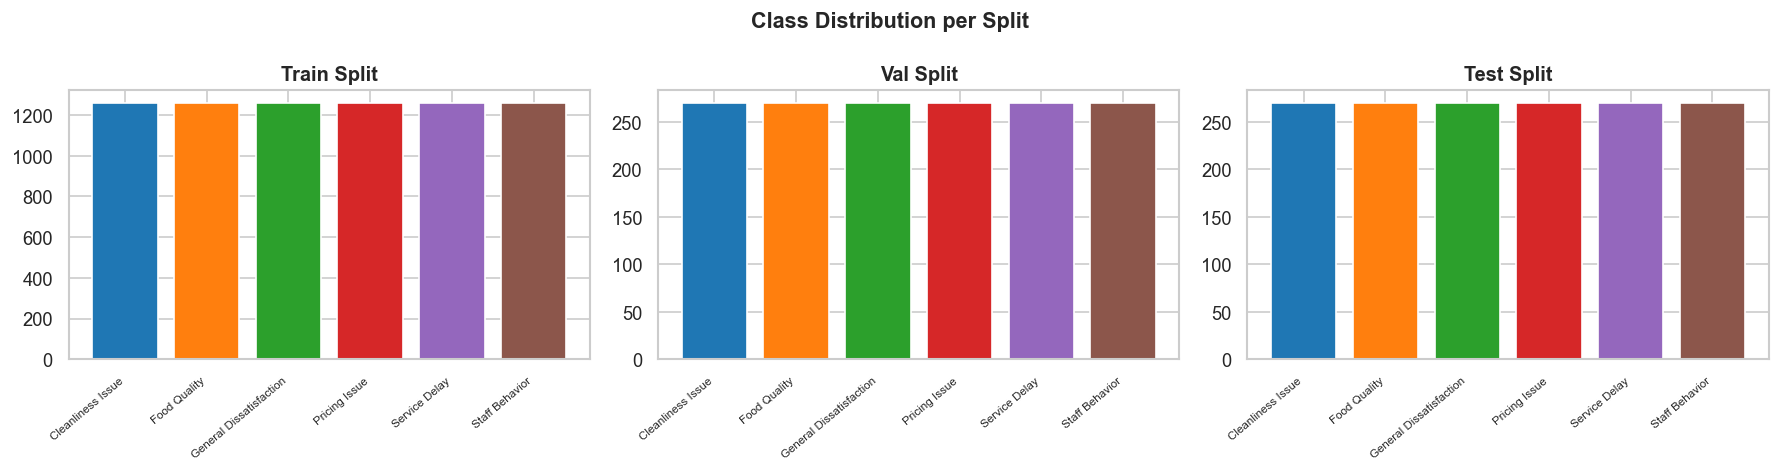

In [17]:
X = df_model['clean_text'].values
y = df_model['label_encoded'].values

# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)
# 15% val, 15% test  (50/50 of temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

print('=' * 55)
print(f'  Train  : {len(X_train):>5,} samples ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Val    : {len(X_val):>5,} samples ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test   : {len(X_test):>5,} samples ({len(X_test)/len(X)*100:.1f}%)')
print('=' * 55)

# Verify stratification
split_dist = pd.DataFrame({
    'Train': np.bincount(y_train),
    'Val'  : np.bincount(y_val),
    'Test' : np.bincount(y_test)
}, index=le.classes_)
split_pct = split_dist.div(split_dist.sum(axis=0), axis=1).mul(100).round(1)

print('\nClass Distribution per Split:')
display(split_dist)
print('\nClass Distribution % per Split (verify stratification):')
display(split_pct)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, counts) in zip(axes, [('Train', np.bincount(y_train)),
                                       ('Val',   np.bincount(y_val)),
                                       ('Test',  np.bincount(y_test))]):
    ax.bar(le.classes_, counts, color=PALETTE)
    ax.set_title(f'{name} Split', fontsize=12, fontweight='bold')
    ax.set_xticklabels(le.classes_, rotation=40, ha='right', fontsize=7)
plt.suptitle('Class Distribution per Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_10_split_distribution.png', bbox_inches='tight')
plt.show()

---
## Phase 9 — Traditional NLP Baselines 📏


  ── Logistic Regression ──
  Accuracy: 0.9278   Macro-F1: 0.9279   Weighted-F1: 0.9279

  Classification Report:
                         precision    recall  f1-score   support

      Cleanliness Issue       0.94      0.93      0.93       270
           Food Quality       0.94      0.91      0.93       270
General Dissatisfaction       0.94      0.94      0.94       270
          Pricing Issue       0.90      0.93      0.91       270
          Service Delay       0.90      0.93      0.91       270
         Staff Behavior       0.96      0.93      0.94       270

               accuracy                           0.93      1620
              macro avg       0.93      0.93      0.93      1620
           weighted avg       0.93      0.93      0.93      1620



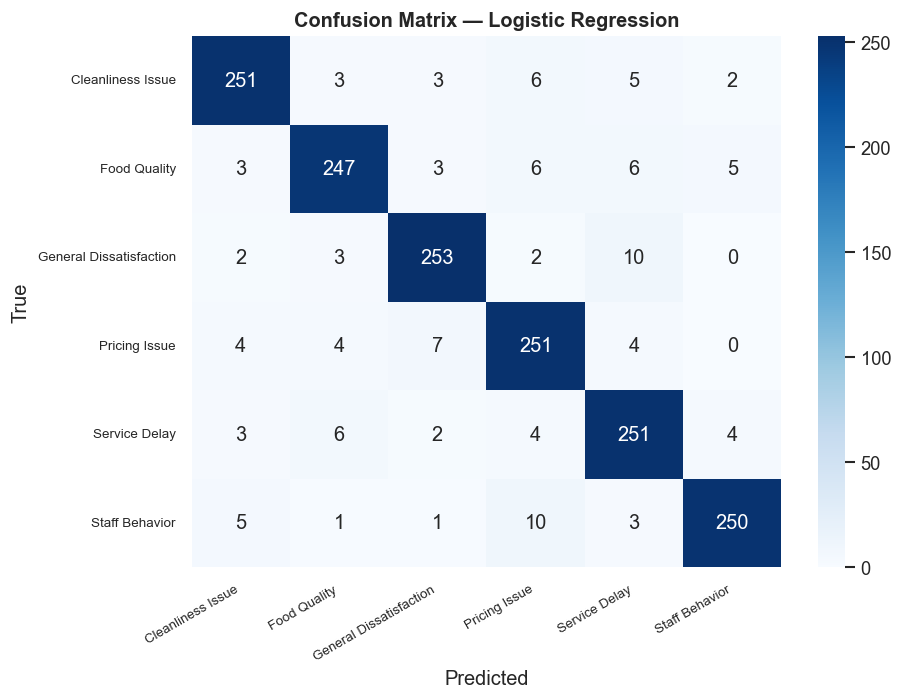


  ── Linear SVM ──
  Accuracy: 0.9327   Macro-F1: 0.9328   Weighted-F1: 0.9328

  Classification Report:
                         precision    recall  f1-score   support

      Cleanliness Issue       0.94      0.94      0.94       270
           Food Quality       0.94      0.90      0.92       270
General Dissatisfaction       0.94      0.94      0.94       270
          Pricing Issue       0.90      0.93      0.92       270
          Service Delay       0.91      0.94      0.92       270
         Staff Behavior       0.97      0.93      0.95       270

               accuracy                           0.93      1620
              macro avg       0.93      0.93      0.93      1620
           weighted avg       0.93      0.93      0.93      1620



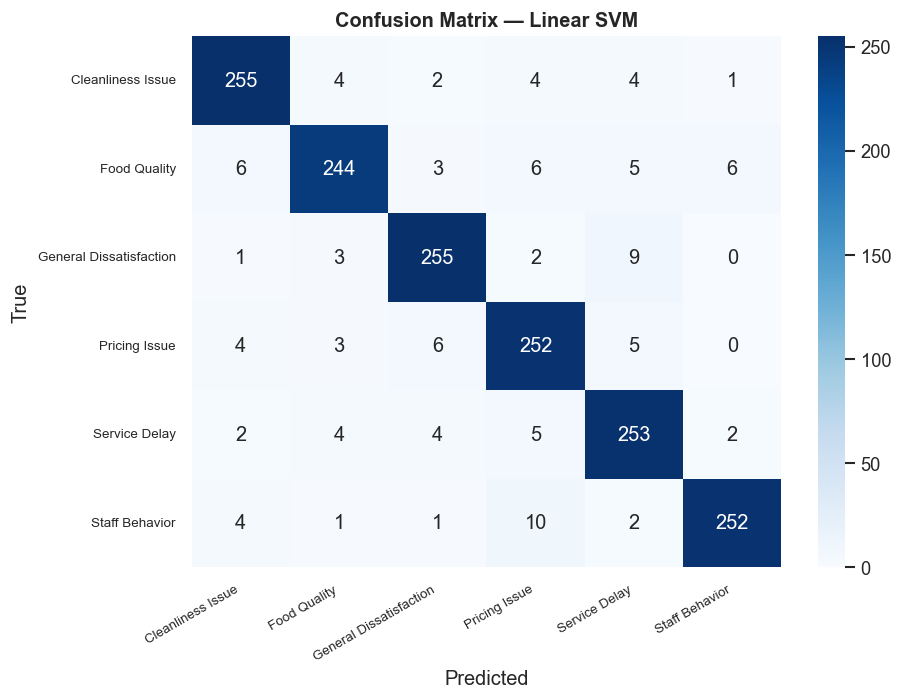


  ── Random Forest ──
  Accuracy: 0.9031   Macro-F1: 0.9032   Weighted-F1: 0.9032

  Classification Report:
                         precision    recall  f1-score   support

      Cleanliness Issue       0.90      0.93      0.91       270
           Food Quality       0.97      0.83      0.89       270
General Dissatisfaction       0.92      0.92      0.92       270
          Pricing Issue       0.86      0.92      0.89       270
          Service Delay       0.86      0.90      0.88       270
         Staff Behavior       0.93      0.93      0.93       270

               accuracy                           0.90      1620
              macro avg       0.91      0.90      0.90      1620
           weighted avg       0.91      0.90      0.90      1620



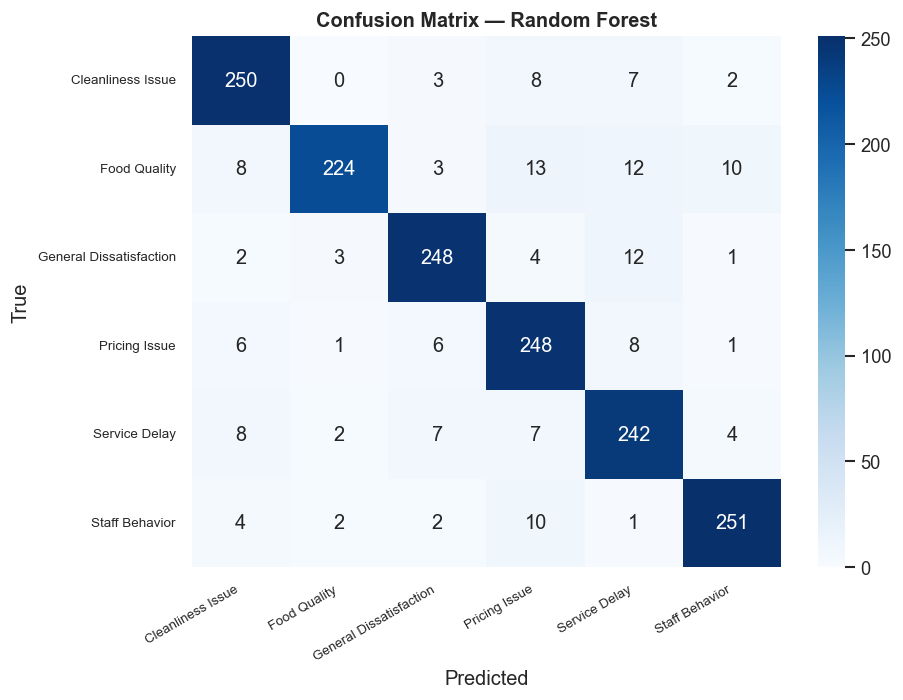


✅ All baseline models evaluated.


In [18]:
def evaluate_pipeline(pipeline, X_tr, y_tr, X_te, y_te, name, class_names):
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)

    metrics = {
        'Model'      : name,
        'Accuracy'   : round(accuracy_score(y_te, y_pred), 4),
        'Precision'  : round(precision_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'Recall'     : round(recall_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'F1'         : round(f1_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'Macro F1'   : round(f1_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'Weighted F1': round(f1_score(y_te, y_pred, average='weighted', zero_division=0), 4),
    }

    print(f'\n  ── {name} ──')
    print(f'  Accuracy: {metrics["Accuracy"]:.4f}   Macro-F1: {metrics["Macro F1"]:.4f}   Weighted-F1: {metrics["Weighted F1"]:.4f}')
    print('\n  Classification Report:')
    print(classification_report(y_te, y_pred, target_names=class_names))

    # Confusion matrix
    cm_ = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm_, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.xticks(rotation=30, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(f'plot_cm_{name.lower().replace(" ","_")}.png', bbox_inches='tight')
    plt.show()

    return metrics, pipeline


class_names = list(le.classes_)
baseline_results = []

# ── Pipeline 1: TF-IDF + Logistic Regression ──────────────────────────────────
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED, class_weight='balanced'))
])
metrics_lr, fitted_lr = evaluate_pipeline(pipe_lr, X_train, y_train, X_test, y_test, 'Logistic Regression', class_names)
baseline_results.append(metrics_lr)

# ── Pipeline 2: TF-IDF + Linear SVM ──────────────────────────────────────────
pipe_svm = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED, class_weight='balanced'))
])
metrics_svm, fitted_svm = evaluate_pipeline(pipe_svm, X_train, y_train, X_test, y_test, 'Linear SVM', class_names)
baseline_results.append(metrics_svm)

# ── Pipeline 3: TF-IDF + Random Forest ───────────────────────────────────────
pipe_rf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 1), sublinear_tf=True)),
    ('clf',   RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_SEED, class_weight='balanced'))
])
metrics_rf, fitted_rf = evaluate_pipeline(pipe_rf, X_train, y_train, X_test, y_test, 'Random Forest', class_names)
baseline_results.append(metrics_rf)

print('\n✅ All baseline models evaluated.')

---
## Phase 10 — Cross Validation 🔄

5-Fold Stratified Cross Validation — Logistic Regression
  Fold Accuracies : [0.921, 0.927, 0.9101, 0.9227, 0.9248]
  Mean Accuracy   : 0.9211  ± 0.0059
  Fold Macro F1   : [0.9211, 0.927, 0.9101, 0.9227, 0.9247]
  Mean Macro F1   : 0.9211  ± 0.0059


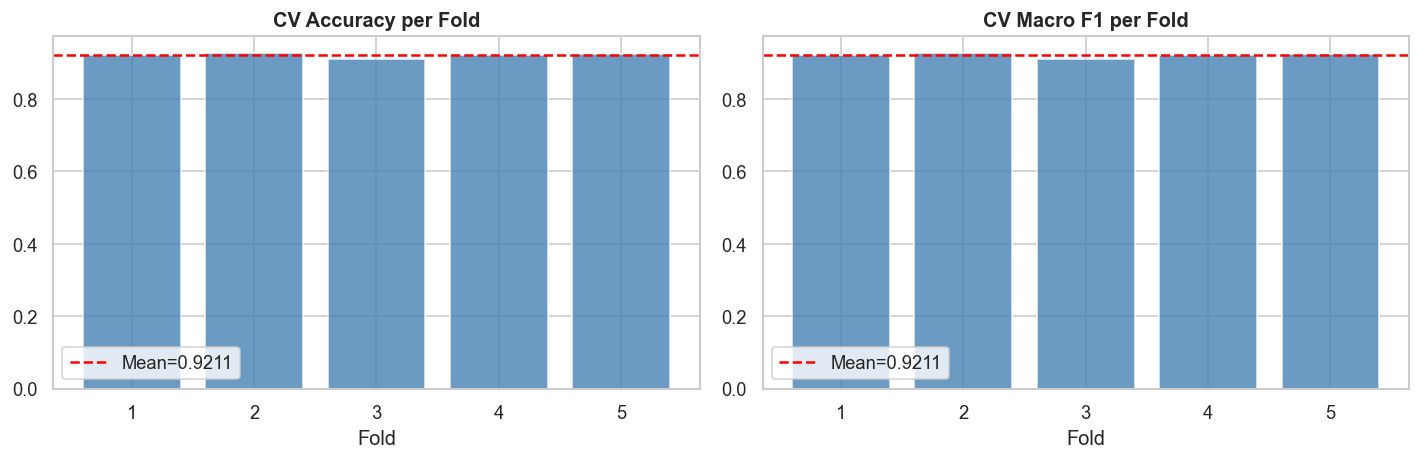

In [19]:
print('5-Fold Stratified Cross Validation — Logistic Regression')

cv_pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED, class_weight='balanced'))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

cv_acc = cross_val_score(cv_pipe_lr, X_all, y_all, cv=skf, scoring='accuracy', n_jobs=-1)
cv_f1  = cross_val_score(cv_pipe_lr, X_all, y_all, cv=skf, scoring='f1_macro', n_jobs=-1)

print('=' * 55)
print(f'  Fold Accuracies : {[round(a, 4) for a in cv_acc]}')
print(f'  Mean Accuracy   : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}')
print(f'  Fold Macro F1   : {[round(f, 4) for f in cv_f1]}')
print(f'  Mean Macro F1   : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}')
print('=' * 55)

# Plot CV results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, scores, title in zip(axes, [cv_acc, cv_f1], ['CV Accuracy per Fold', 'CV Macro F1 per Fold']):
    ax.bar(range(1, 6), scores, color='steelblue', alpha=0.8)
    ax.axhline(scores.mean(), color='red', linestyle='--', label=f'Mean={scores.mean():.4f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.legend()
plt.tight_layout()
plt.savefig('plot_11_cross_validation.png', bbox_inches='tight')
plt.show()

---
## Phase 11 — Custom Transformer Architecture 🧠
> Built entirely from scratch using native PyTorch. No HuggingFace, no pretrained weights.

In [20]:
# ── Model Configuration ───────────────────────────────────────────────────────
MAX_LEN        = 128
MAX_VOCAB_SIZE = 20000
EMBED_DIM      = 256
NUM_HEADS      = 4
NUM_LAYERS     = 3
FF_DIM         = 512
DROPOUT        = 0.2
NUM_CLASSES    = 6

print('Model Configuration:')
cfg = dict(MAX_LEN=MAX_LEN, MAX_VOCAB_SIZE=MAX_VOCAB_SIZE, EMBED_DIM=EMBED_DIM,
           NUM_HEADS=NUM_HEADS, NUM_LAYERS=NUM_LAYERS, FF_DIM=FF_DIM,
           DROPOUT=DROPOUT, NUM_CLASSES=NUM_CLASSES)
for k, v in cfg.items():
    print(f'  {k:<20}: {v}')

Model Configuration:
  MAX_LEN             : 128
  MAX_VOCAB_SIZE      : 20000
  EMBED_DIM           : 256
  NUM_HEADS           : 4
  NUM_LAYERS          : 3
  FF_DIM              : 512
  DROPOUT             : 0.2
  NUM_CLASSES         : 6


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# TOKEN EMBEDDING
# ─────────────────────────────────────────────────────────────────────────────
class TokenEmbedding(nn.Module):
    """Learnable token embedding with padding index = 0."""
    def __init__(self, vocab_size: int, embed_dim: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embed_dim = embed_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T] → out: [B, T, embed_dim]
        return self.embedding(x) * math.sqrt(self.embed_dim)


# ─────────────────────────────────────────────────────────────────────────────
# POSITIONAL EMBEDDING (sinusoidal, non-learnable)
# ─────────────────────────────────────────────────────────────────────────────
class PositionalEmbedding(nn.Module):
    """Fixed sinusoidal positional encoding (Vaswani et al. 2017)."""
    def __init__(self, max_len: int, embed_dim: int, dropout: float):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, embed_dim)                    # [T, D]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # [T, 1]
        div_term = torch.exp(
            torch.arange(0, embed_dim, 2, dtype=torch.float) * -(math.log(10000.0) / embed_dim)
        )  # [D/2]
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)                                    # [1, T, D]
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, D]
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


print('✅ TokenEmbedding and PositionalEmbedding defined.')

✅ TokenEmbedding and PositionalEmbedding defined.


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# MULTI-HEAD SELF ATTENTION
# ─────────────────────────────────────────────────────────────────────────────
class MultiHeadSelfAttention(nn.Module):
    """Scaled Dot-Product Multi-Head Self-Attention (from scratch)."""
    def __init__(self, embed_dim: int, num_heads: int, dropout: float):
        super().__init__()
        assert embed_dim % num_heads == 0, 'embed_dim must be divisible by num_heads'

        self.embed_dim  = embed_dim
        self.num_heads  = num_heads
        self.head_dim   = embed_dim // num_heads
        self.scale      = math.sqrt(self.head_dim)

        # Projection matrices for Q, K, V and output
        self.W_q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_o = nn.Linear(embed_dim, embed_dim)

        self.attn_dropout = nn.Dropout(p=dropout)

    def forward(
        self,
        x: torch.Tensor,
        key_padding_mask: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        B, T, D = x.shape
        H, dh   = self.num_heads, self.head_dim

        # Project and reshape to [B, H, T, dh]
        Q = self.W_q(x).view(B, T, H, dh).transpose(1, 2)  # [B, H, T, dh]
        K = self.W_k(x).view(B, T, H, dh).transpose(1, 2)
        V = self.W_v(x).view(B, T, H, dh).transpose(1, 2)

        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale  # [B, H, T, T]

        # Apply padding mask (True = ignore)
        if key_padding_mask is not None:
            scores = scores.masked_fill(
                key_padding_mask.unsqueeze(1).unsqueeze(2), float('-inf')
            )

        attn_weights = F.softmax(scores, dim=-1)          # [B, H, T, T]
        attn_weights = self.attn_dropout(attn_weights)

        # Weighted sum over values
        context = torch.matmul(attn_weights, V)           # [B, H, T, dh]
        context = context.transpose(1, 2).contiguous().view(B, T, D)  # [B, T, D]

        return self.W_o(context)


print('✅ MultiHeadSelfAttention defined.')

✅ MultiHeadSelfAttention defined.


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# FEED-FORWARD NETWORK
# ─────────────────────────────────────────────────────────────────────────────
class FeedForwardNetwork(nn.Module):
    """Position-wise FFN: Linear → GELU → Dropout → Linear."""
    def __init__(self, embed_dim: int, ff_dim: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(p=dropout),
            nn.Linear(ff_dim, embed_dim),
            nn.Dropout(p=dropout)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# ─────────────────────────────────────────────────────────────────────────────
# TRANSFORMER ENCODER BLOCK
# ─────────────────────────────────────────────────────────────────────────────
class TransformerEncoderBlock(nn.Module):
    """
    Pre-LN Transformer Encoder Block:
      x → LayerNorm → MHSA → Residual → LayerNorm → FFN → Residual
    """
    def __init__(self, embed_dim: int, num_heads: int, ff_dim: int, dropout: float):
        super().__init__()
        self.norm1      = nn.LayerNorm(embed_dim)
        self.attn       = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2      = nn.LayerNorm(embed_dim)
        self.ffn        = FeedForwardNetwork(embed_dim, ff_dim, dropout)
        self.dropout    = nn.Dropout(p=dropout)

    def forward(
        self,
        x: torch.Tensor,
        key_padding_mask: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        # Sub-layer 1: MHSA with residual
        residual = x
        x = self.norm1(x)
        x = self.attn(x, key_padding_mask=key_padding_mask)
        x = self.dropout(x)
        x = residual + x

        # Sub-layer 2: FFN with residual
        residual = x
        x = self.norm2(x)
        x = self.ffn(x)
        x = residual + x

        return x


print('✅ FeedForwardNetwork and TransformerEncoderBlock defined.')

✅ FeedForwardNetwork and TransformerEncoderBlock defined.


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPLETE CUSTOM TRANSFORMER CLASSIFIER
# ─────────────────────────────────────────────────────────────────────────────
class ComplaintTransformer(nn.Module):
    """
    Custom Transformer Encoder for complaint classification.

    Architecture:
      Input → TokenEmbedding → PositionalEmbedding
            → TransformerEncoderBlock × num_layers
            → Mean Pooling (over non-padded positions)
            → Dense Layer → GELU → Dropout
            → Output Layer → 6-class LogSoftmax
    """
    def __init__(
        self,
        vocab_size:  int,
        num_classes: int,
        embed_dim:   int = EMBED_DIM,
        num_heads:   int = NUM_HEADS,
        num_layers:  int = NUM_LAYERS,
        ff_dim:      int = FF_DIM,
        max_len:     int = MAX_LEN,
        dropout:     float = DROPOUT
    ):
        super().__init__()
        self.token_embedding    = TokenEmbedding(vocab_size, embed_dim)
        self.positional_embedding = PositionalEmbedding(max_len, embed_dim, dropout)

        self.encoder_blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

        self.norm       = nn.LayerNorm(embed_dim)

        # Classification head
        self.dense      = nn.Linear(embed_dim, embed_dim // 2)
        self.act        = nn.GELU()
        self.dropout    = nn.Dropout(p=dropout)
        self.classifier = nn.Linear(embed_dim // 2, num_classes)

    def forward(
        self,
        input_ids: torch.Tensor,           # [B, T] (int token IDs)
        attention_mask: Optional[torch.Tensor] = None  # [B, T] (1=real, 0=pad)
    ) -> torch.Tensor:
        # Padding mask for attention: True where padded
        if attention_mask is not None:
            key_padding_mask = (attention_mask == 0)   # [B, T]
        else:
            key_padding_mask = None

        # Embeddings
        x = self.token_embedding(input_ids)             # [B, T, D]
        x = self.positional_embedding(x)                # [B, T, D]

        # Transformer encoder blocks
        for block in self.encoder_blocks:
            x = block(x, key_padding_mask=key_padding_mask)

        x = self.norm(x)                                # [B, T, D]

        # Mean pooling — average only over non-padded positions
        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1).float() # [B, T, 1]
            x = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)  # [B, D]
        else:
            x = x.mean(dim=1)                           # [B, D]

        # Classification head
        x = self.dense(x)       # [B, D//2]
        x = self.act(x)
        x = self.dropout(x)
        logits = self.classifier(x)  # [B, num_classes]

        return logits

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


print('✅ ComplaintTransformer model class defined.')
print('\n  Architecture summary will be printed after vocabulary creation.')

✅ ComplaintTransformer model class defined.

  Architecture summary will be printed after vocabulary creation.


---
## Phase 12 — Vocabulary Creation 📖

In [25]:
# Build vocabulary ONLY from TRAINING data
PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'

def tokenize(text: str) -> List[str]:
    return text.lower().split()

def build_vocabulary(texts: List[str], max_size: int = MAX_VOCAB_SIZE) -> Dict[str, int]:
    """Build word-level vocabulary from training corpus only."""
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    # Reserve 0 for <pad>, 1 for <unk>
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for word, _ in counter.most_common(max_size - 2):
        vocab[word] = len(vocab)

    return vocab


vocab = build_vocabulary(X_train.tolist(), MAX_VOCAB_SIZE)

# Effective vocab size (may be smaller than MAX_VOCAB_SIZE)
ACTUAL_VOCAB_SIZE = len(vocab)

print(f'Vocabulary size     : {ACTUAL_VOCAB_SIZE:,} tokens')
print(f'Max vocab ceiling   : {MAX_VOCAB_SIZE:,}')
print(f'Special tokens      : {PAD_TOKEN} (0), {UNK_TOKEN} (1)')
print(f'Sample vocab entries: {dict(list(vocab.items())[2:12])}')

# Save vocabulary
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)
print('\n✅ vocab.pkl saved')


def text_to_ids(text: str, vocab: Dict[str, int], max_len: int = MAX_LEN) -> Tuple[List[int], List[int]]:
    """Convert text to padded token IDs and attention mask."""
    tokens = tokenize(text)[:max_len]
    ids    = [vocab.get(tok, vocab[UNK_TOKEN]) for tok in tokens]
    pad_len = max_len - len(ids)
    mask    = [1] * len(ids) + [0] * pad_len
    ids     = ids + [vocab[PAD_TOKEN]] * pad_len
    return ids, mask

Vocabulary size     : 1,128 tokens
Max vocab ceiling   : 20,000
Special tokens      : <pad> (0), <unk> (1)
Sample vocab entries: {'the': 2, 'was': 3, 'i': 4, 'to': 5, 'a': 6, 'and': 7, 'it': 8, 'not': 9, 'this': 10, 'for': 11}

✅ vocab.pkl saved


---
## Phase 13 — Training Configuration ⚙️

In [26]:
# ── Hyper-parameters ──────────────────────────────────────────────────────────
BATCH_SIZE    = 32
EPOCHS        = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 0.01
GRAD_CLIP     = 1.0
PATIENCE      = 3     # early stopping

print('Training Configuration:')
train_cfg = dict(BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS, LEARNING_RATE=LEARNING_RATE,
                 WEIGHT_DECAY=WEIGHT_DECAY, GRAD_CLIP=GRAD_CLIP, PATIENCE=PATIENCE,
                 OPTIMIZER='AdamW', SCHEDULER='ReduceLROnPlateau')
for k, v in train_cfg.items():
    print(f'  {k:<25}: {v}')


# ── PyTorch Dataset ───────────────────────────────────────────────────────────
class ComplaintDataset(Dataset):
    def __init__(self, texts: np.ndarray, labels: np.ndarray,
                 vocab: Dict[str, int], max_len: int = MAX_LEN):
        self.texts   = texts
        self.labels  = labels
        self.vocab   = vocab
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        ids, mask = text_to_ids(str(self.texts[idx]), self.vocab, self.max_len)
        return {
            'input_ids'      : torch.tensor(ids, dtype=torch.long),
            'attention_mask' : torch.tensor(mask, dtype=torch.long),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_ds  = ComplaintDataset(X_train, y_train, vocab)
val_ds    = ComplaintDataset(X_val,   y_val,   vocab)
test_ds   = ComplaintDataset(X_test,  y_test,  vocab)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'\nDataLoaders created:')
print(f'  Train batches : {len(train_loader)}')
print(f'  Val   batches : {len(val_loader)}')
print(f'  Test  batches : {len(test_loader)}')

Training Configuration:
  BATCH_SIZE               : 32
  EPOCHS                   : 10
  LEARNING_RATE            : 0.001
  WEIGHT_DECAY             : 0.01
  GRAD_CLIP                : 1.0
  PATIENCE                 : 3
  OPTIMIZER                : AdamW
  SCHEDULER                : ReduceLROnPlateau

DataLoaders created:
  Train batches : 237
  Val   batches : 51
  Test  batches : 51


---
## Phase 14 — Device Optimization 💻

In [27]:
# Priority: MPS > CUDA > CPU
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'  GPU Name : {torch.cuda.get_device_name(0)}')
    print(f'  GPU Mem  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    DEVICE = torch.device('cpu')

print(f'\n🖥️  Selected Device: {DEVICE}')

# Instantiate model
model = ComplaintTransformer(
    vocab_size  = ACTUAL_VOCAB_SIZE,
    num_classes = NUM_CLASSES,
    embed_dim   = EMBED_DIM,
    num_heads   = NUM_HEADS,
    num_layers  = NUM_LAYERS,
    ff_dim      = FF_DIM,
    max_len     = MAX_LEN,
    dropout     = DROPOUT
).to(DEVICE)

n_params = model.count_parameters()
print(f'\n✅ Model instantiated on {DEVICE}')
print(f'   Trainable Parameters: {n_params:,}')

# Optimizer & Scheduler
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print('   Optimizer : AdamW')
print('   Scheduler : ReduceLROnPlateau (factor=0.5, patience=2)')
print('   Loss      : CrossEntropyLoss (label_smoothing=0.1)')


🖥️  Selected Device: mps

✅ Model instantiated on mps
   Trainable Parameters: 1,901,958
   Optimizer : AdamW
   Scheduler : ReduceLROnPlateau (factor=0.5, patience=2)
   Loss      : CrossEntropyLoss (label_smoothing=0.1)


---
## Training Loop 🚀

In [28]:
def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE, phase='train'):
    """Single training or validation epoch."""
    model.train() if phase == 'train' else model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    ctx = torch.enable_grad() if phase == 'train' else torch.no_grad()
    with ctx:
        for batch in loader:
            input_ids  = batch['input_ids'].to(device)
            attn_mask  = batch['attention_mask'].to(device)
            labels     = batch['label'].to(device)

            logits = model(input_ids, attn_mask)            # [B, C]
            loss   = criterion(logits, labels)

            if phase == 'train':
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

            preds = logits.argmax(dim=-1)
            total_loss    += loss.item() * labels.size(0)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


# ── Training Loop ─────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
patience_counter = 0
best_epoch = 0

print(f'Training for up to {EPOCHS} epochs (early stopping patience={PATIENCE})...')
print('=' * 70)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, DEVICE, 'train')
    va_loss, va_acc = run_epoch(model, val_loader,   criterion, None,      DEVICE, 'val')

    scheduler.step(va_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'  ].append(va_loss)
    history['train_acc' ].append(tr_acc)
    history['val_acc'   ].append(va_acc)

    print(f'Epoch [{epoch:2d}/{EPOCHS}] | '
          f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | '
          f'Val Loss: {va_loss:.4f}  Acc: {va_acc:.4f}'
          + (' ← best' if va_loss < best_val_loss else ''))

    if va_loss < best_val_loss:
        best_val_loss    = va_loss
        best_epoch       = epoch
        patience_counter = 0
        torch.save(model.state_dict(), 'complaint_transformer_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\n⏹️  Early stopping triggered at epoch {epoch}. Best epoch: {best_epoch}')
            break

print('=' * 70)
print(f'\nTraining complete. Best model from epoch {best_epoch} saved to complaint_transformer_model.pth')

Training for up to 10 epochs (early stopping patience=3)...
Epoch [ 1/10] | Train Loss: 0.9380  Acc: 0.7676 | Val Loss: 0.6722  Acc: 0.9080 ← best
Epoch [ 2/10] | Train Loss: 0.6114  Acc: 0.9190 | Val Loss: 0.6752  Acc: 0.9025
Epoch [ 3/10] | Train Loss: 0.5830  Acc: 0.9294 | Val Loss: 0.6364  Acc: 0.9154 ← best
Epoch [ 4/10] | Train Loss: 0.5570  Acc: 0.9417 | Val Loss: 0.5913  Acc: 0.9173 ← best
Epoch [ 5/10] | Train Loss: 0.5393  Acc: 0.9452 | Val Loss: 0.6125  Acc: 0.9130
Epoch [ 6/10] | Train Loss: 0.5293  Acc: 0.9505 | Val Loss: 0.6019  Acc: 0.9167
Epoch [ 7/10] | Train Loss: 0.5196  Acc: 0.9577 | Val Loss: 0.5909  Acc: 0.9142 ← best
Epoch [ 8/10] | Train Loss: 0.5105  Acc: 0.9618 | Val Loss: 0.5991  Acc: 0.9167
Epoch [ 9/10] | Train Loss: 0.5038  Acc: 0.9618 | Val Loss: 0.5987  Acc: 0.9148
Epoch [10/10] | Train Loss: 0.5003  Acc: 0.9671 | Val Loss: 0.5872  Acc: 0.9204 ← best

Training complete. Best model from epoch 10 saved to complaint_transformer_model.pth


---
## Phase 15 — Training Visualization 📊

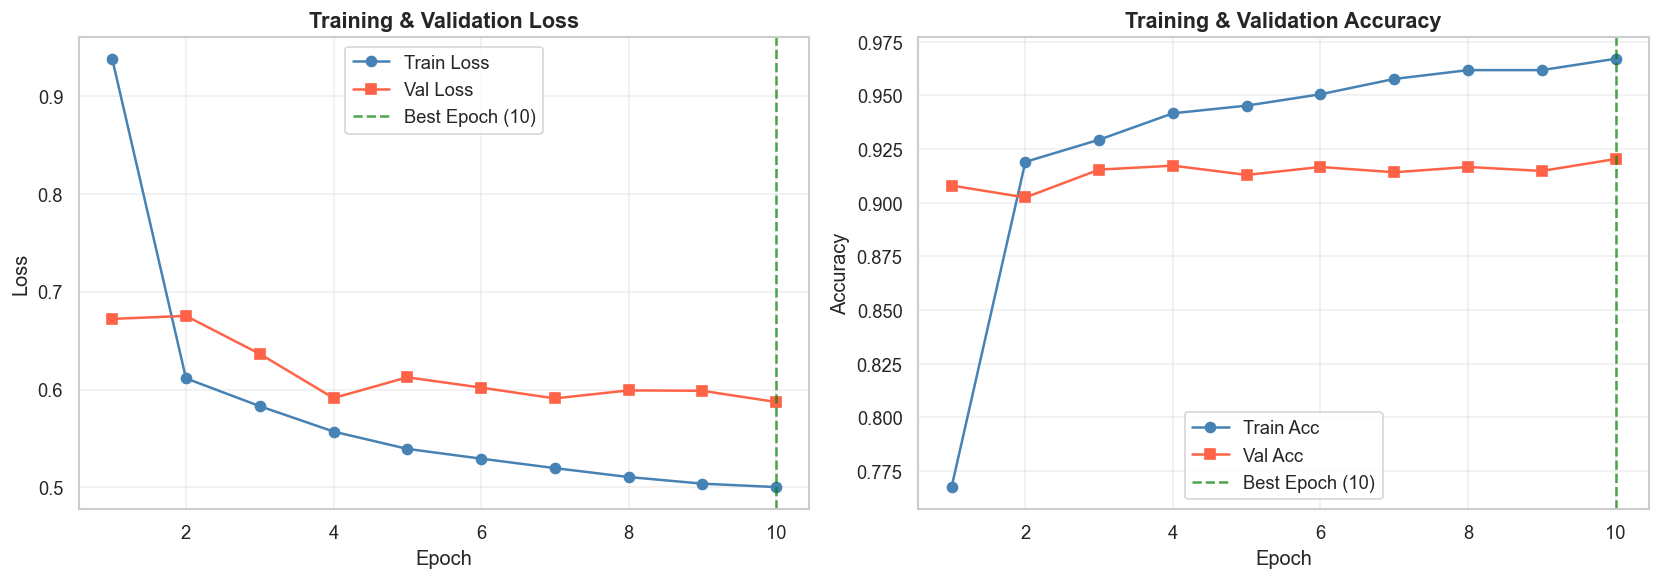

In [29]:
epochs_ran = list(range(1, len(history['train_loss']) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss', marker='o', color='steelblue')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss',   marker='s', color='tomato')
axes[0].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
axes[0].set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(epochs_ran, history['train_acc'], label='Train Acc', marker='o', color='steelblue')
axes[1].plot(epochs_ran, history['val_acc'],   label='Val Acc',   marker='s', color='tomato')
axes[1].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
axes[1].set_title('Training & Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_12_training_curves.png', bbox_inches='tight')
plt.show()

---
## Phase 16 — Model Evaluation 🎯

  CUSTOM TRANSFORMER — TEST SET EVALUATION
  Accuracy    : 0.9352
  Precision   : 0.9357
  Recall      : 0.9352
  F1 Score    : 0.9351
  Macro F1    : 0.9351
  Weighted F1 : 0.9351

Classification Report:
                         precision    recall  f1-score   support

      Cleanliness Issue     0.9078    0.9481    0.9275       270
           Food Quality     0.9245    0.9519    0.9380       270
General Dissatisfaction     0.9353    0.9630    0.9489       270
          Pricing Issue     0.9331    0.9296    0.9314       270
          Service Delay     0.9442    0.8778    0.9098       270
         Staff Behavior     0.9695    0.9407    0.9549       270

               accuracy                         0.9352      1620
              macro avg     0.9357    0.9352    0.9351      1620
           weighted avg     0.9357    0.9352    0.9351      1620


Per-Class Metrics:


,Precision,Recall,F1,Support
Cleanliness Issue,0.9078,0.9481,0.9275,270.0
Food Quality,0.9245,0.9519,0.9380,270.0
General Dissatisfaction,0.9353,0.9630,0.9489,270.0
Pricing Issue,0.9331,0.9296,0.9314,270.0
Service Delay,0.9442,0.8778,0.9098,270.0
Staff Behavior,0.9695,0.9407,0.9549,270.0


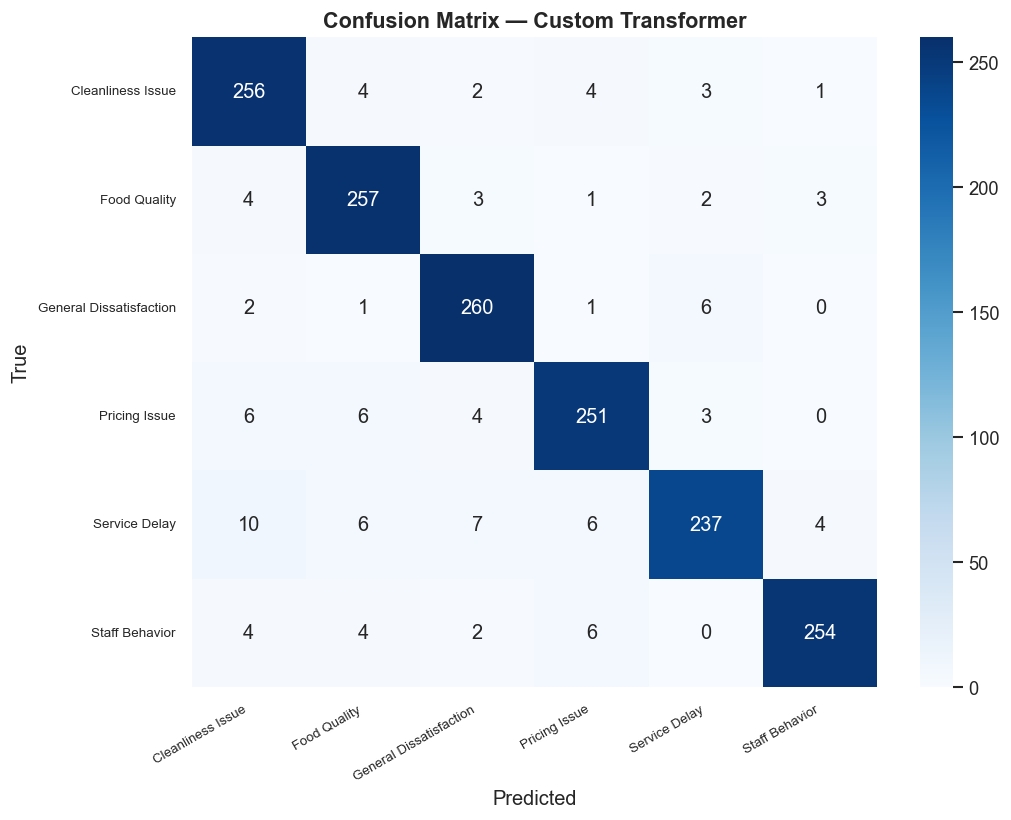

In [30]:
# Load best checkpoint
model.load_state_dict(torch.load('complaint_transformer_model.pth', map_location=DEVICE))
model.eval()

all_preds, all_probs, all_true = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels    = batch['label']

        logits = model(input_ids, attn_mask)
        probs  = F.softmax(logits, dim=-1).cpu().numpy()
        preds  = logits.argmax(dim=-1).cpu().numpy()

        all_preds.extend(preds)
        all_probs.extend(probs)
        all_true.extend(labels.numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_true  = np.array(all_true)

# ── Metrics ───────────────────────────────────────────────────────────────────
tf_acc  = accuracy_score(all_true, all_preds)
tf_prec = precision_score(all_true, all_preds, average='weighted', zero_division=0)
tf_rec  = recall_score(all_true, all_preds, average='weighted', zero_division=0)
tf_f1   = f1_score(all_true, all_preds, average='weighted', zero_division=0)
tf_mf1  = f1_score(all_true, all_preds, average='macro', zero_division=0)
tf_wf1  = f1_score(all_true, all_preds, average='weighted', zero_division=0)

print('=' * 60)
print('  CUSTOM TRANSFORMER — TEST SET EVALUATION')
print('=' * 60)
print(f'  Accuracy    : {tf_acc:.4f}')
print(f'  Precision   : {tf_prec:.4f}')
print(f'  Recall      : {tf_rec:.4f}')
print(f'  F1 Score    : {tf_f1:.4f}')
print(f'  Macro F1    : {tf_mf1:.4f}')
print(f'  Weighted F1 : {tf_wf1:.4f}')
print('=' * 60)

print('\nClassification Report:')
print(classification_report(all_true, all_preds, target_names=class_names, digits=4))

# Per-class metrics table
per_class_data = {}
for i, cls in enumerate(class_names):
    mask_i = all_true == i
    per_class_data[cls] = {
        'Precision': round(precision_score(all_true == i, all_preds == i, zero_division=0), 4),
        'Recall'   : round(recall_score(all_true == i, all_preds == i, zero_division=0), 4),
        'F1'       : round(f1_score(all_true == i, all_preds == i, zero_division=0), 4),
        'Support'  : int(mask_i.sum())
    }
print('\nPer-Class Metrics:')
display(pd.DataFrame(per_class_data).T)

# Confusion Matrix
cm_tf = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_tf, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Confusion Matrix — Custom Transformer', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('plot_13_transformer_cm.png', bbox_inches='tight')
plt.show()

# Store transformer metrics
metrics_tf = {
    'Model'      : 'Custom Transformer',
    'Accuracy'   : round(tf_acc, 4),
    'Precision'  : round(tf_prec, 4),
    'Recall'     : round(tf_rec, 4),
    'F1'         : round(tf_f1, 4),
    'Macro F1'   : round(tf_mf1, 4),
    'Weighted F1': round(tf_wf1, 4),
}

---
## Phase 17 — Model Comparison 🏆

  MODEL COMPARISON TABLE


,Accuracy,Precision,Recall,F1,Macro F1,Weighted F1
Model,,,,,,
Logistic Regression,0.9278,0.9283,0.9278,0.9279,0.9279,0.9279
Linear SVM,0.9327,0.9332,0.9327,0.9328,0.9328,0.9328
Random Forest,0.9031,0.9055,0.9031,0.9032,0.9032,0.9032
Custom Transformer,0.9352,0.9357,0.9352,0.9351,0.9351,0.9351



🏆 Best Model by Weighted F1: Custom Transformer (0.9351)


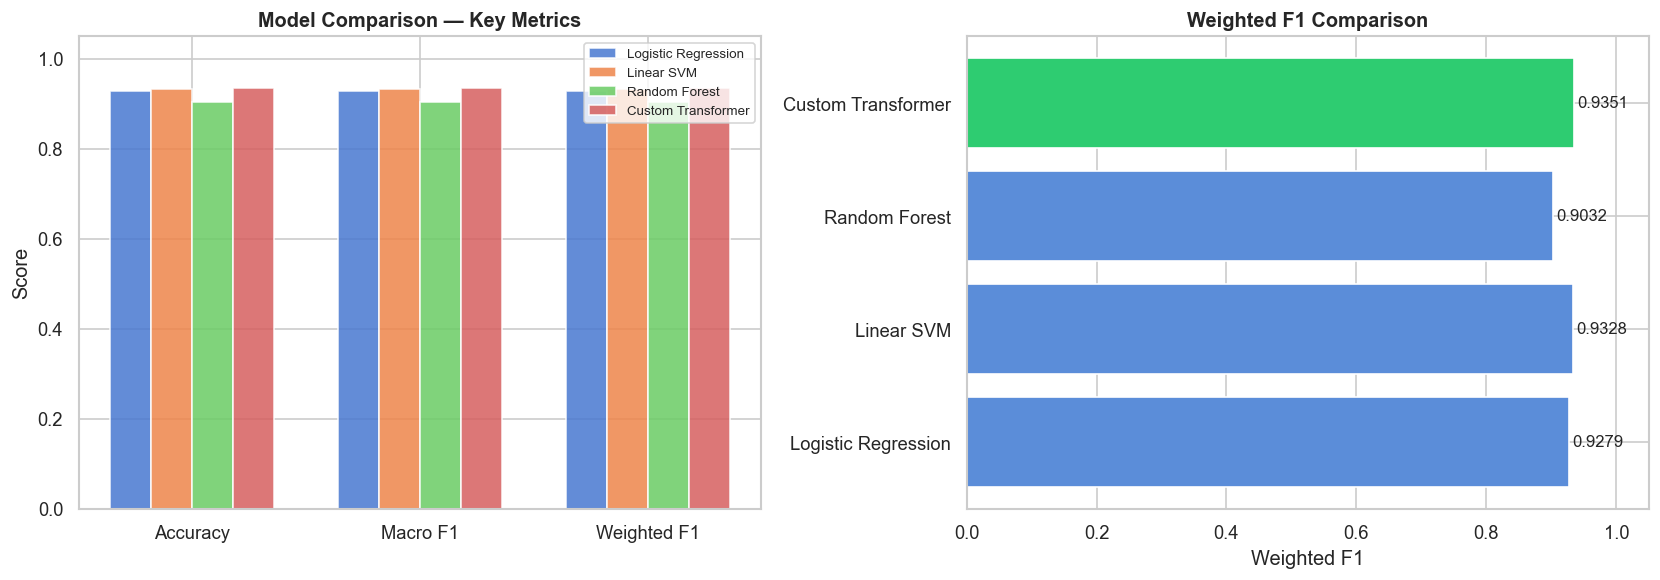

In [31]:
all_results = baseline_results + [metrics_tf]
comparison_df = pd.DataFrame(all_results).set_index('Model')

print('=' * 70)
print('  MODEL COMPARISON TABLE')
print('=' * 70)
display(comparison_df.style
        .format('{:.4f}')
        .highlight_max(axis=0, color='lightgreen')
        .highlight_min(axis=0, color='#ffcccc')
        .set_caption('Green = Best  |  Red = Worst per metric'))

best_model = comparison_df['Weighted F1'].idxmax()
print(f'\n🏆 Best Model by Weighted F1: {best_model} ({comparison_df.loc[best_model, "Weighted F1"]:.4f})')

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics_to_plot = ['Accuracy', 'Macro F1', 'Weighted F1']

x = np.arange(len(metrics_to_plot))
bar_width = 0.18
models = comparison_df.index.tolist()

for i, model_name in enumerate(models):
    vals = [comparison_df.loc[model_name, m] for m in metrics_to_plot]
    axes[0].bar(x + i * bar_width, vals, bar_width, label=model_name, alpha=0.85)

axes[0].set_title('Model Comparison — Key Metrics', fontsize=12, fontweight='bold')
axes[0].set_xticks(x + bar_width * (len(models) - 1) / 2)
axes[0].set_xticklabels(metrics_to_plot)
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8)
axes[0].set_ylabel('Score')

# Weighted F1 only
wf1_vals = [comparison_df.loc[m, 'Weighted F1'] for m in models]
colors   = ['#5b8dd9' if m != best_model else '#2ecc71' for m in models]
axes[1].barh(models, wf1_vals, color=colors)
axes[1].set_xlim(0, 1.05)
axes[1].set_title('Weighted F1 Comparison', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Weighted F1')
for i, v in enumerate(wf1_vals):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('plot_14_model_comparison.png', bbox_inches='tight')
plt.show()

---
## Phase 18 — Error Analysis 🔬

Total Errors: 105  (6.5% error rate)

Top 10 Misclassification Pairs:


,true_label,pred_label,count
18,Service Delay,Cleanliness Issue,10
20,Service Delay,General Dissatisfaction,7
13,General Dissatisfaction,Service Delay,6
14,Pricing Issue,Cleanliness Issue,6
21,Service Delay,Pricing Issue,6
19,Service Delay,Food Quality,6
15,Pricing Issue,Food Quality,6
26,Staff Behavior,Pricing Issue,6
0,Cleanliness Issue,Food Quality,4
24,Staff Behavior,Food Quality,4


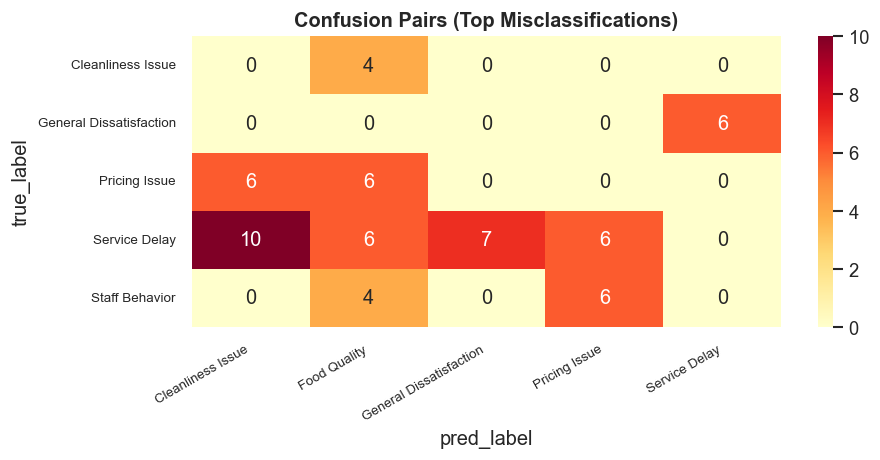


Lowest Confidence Predictions (10 samples):


,text,true_label,pred_label,confidence,correct
56,"i really wanted to like this place, but the line moved painfully slowly, and...",Service Delay,Pricing Issue,0.417053,False
1415,"honestly, communication from the food court stall was unclear from start to ...",Staff Behavior,General Dissatisfaction,0.425454,False
388,"i have to say, the delivery was supposed to come in 30 minutes but took near...",Service Delay,Cleanliness Issue,0.431030,False
990,"to be fair, we waited almost 45 minutes just to get our food at the theatre ...",Service Delay,Service Delay,0.435592,True
637,"not going to lie, the the receptionist handled food without gloves, which fe...",Cleanliness Issue,Food Quality,0.443176,False
1439,nobody explained what was happening or why there was a delay. it definitely ...,Staff Behavior,Staff Behavior,0.448938,True
1043,"honestly, the restroom smelled bad and looked like it had not been cleaned i...",Cleanliness Issue,Service Delay,0.451674,False
1028,we spotted what looked like rodent droppings near the kitchen area. adding t...,Cleanliness Issue,Service Delay,0.457960,False
26,"i have visited a few times before, and i bit into the club sandwich and real...",Food Quality,Food Quality,0.458880,True
1452,there was an unexpected delivery fee added at checkout that was not shown ea...,Pricing Issue,Pricing Issue,0.460672,True



Highest Confidence Predictions (10 samples):


,text,true_label,pred_label,confidence,correct
1586,"honestly, there were way more people than the space could comfortably handle...",General Dissatisfaction,General Dissatisfaction,0.969833,True
1010,"i have to say, we had a genuinely great experience from start to finish. it ...",General Dissatisfaction,General Dissatisfaction,0.967975,True
226,"i have to say, the dining area felt oddly dark and gloomy for a dinner spot....",General Dissatisfaction,General Dissatisfaction,0.967564,True
776,"this was my first time here, and between the slow service, the mediocre food...",General Dissatisfaction,General Dissatisfaction,0.966972,True
69,"this was my first time here, and tables were crammed so close together it fe...",General Dissatisfaction,General Dissatisfaction,0.966931,True
255,"i have visited a few times before, and nothing specific stood out as terribl...",General Dissatisfaction,General Dissatisfaction,0.966786,True
1136,"this was my first time here, and the music was so loud we could barely hear ...",General Dissatisfaction,General Dissatisfaction,0.966603,True
1410,"between the slow service, the mediocre food, and the noise, the whole visit ...",General Dissatisfaction,General Dissatisfaction,0.966235,True
615,"i have to say, a few small things added up to make the visit disappointing.",General Dissatisfaction,General Dissatisfaction,0.965215,True
981,"i have to say, there were way more people than the space could comfortably h...",General Dissatisfaction,General Dissatisfaction,0.965182,True



False Positives / Negatives per Class:


,FP,FN
Class,,
Cleanliness Issue,26,14
Food Quality,21,13
General Dissatisfaction,18,10
Pricing Issue,18,19
Service Delay,14,33
Staff Behavior,8,16


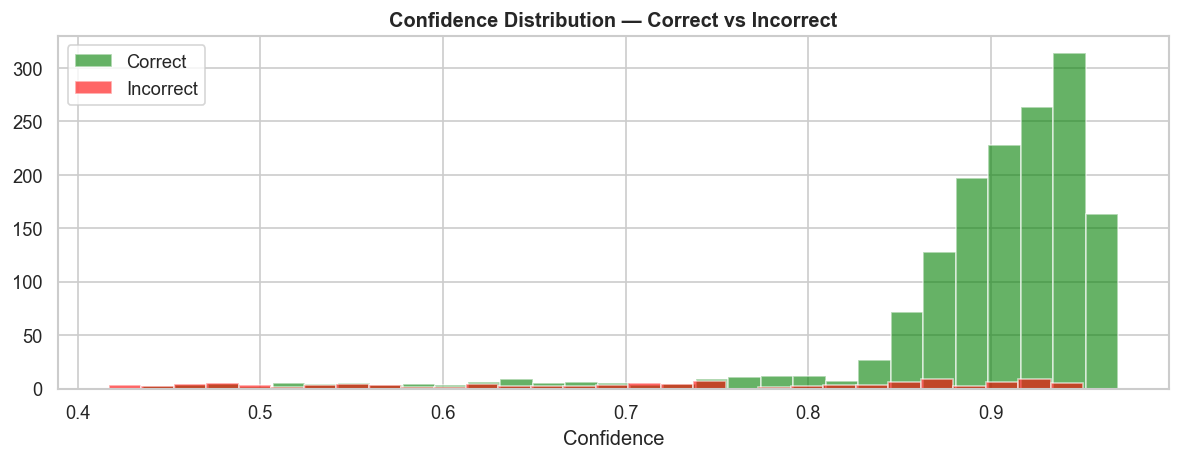


✅ Error analysis complete.


In [32]:
# Build test dataframe for analysis
df_test_analysis = pd.DataFrame({
    'text'            : X_test,
    'true_label'      : [le.classes_[i] for i in all_true],
    'pred_label'      : [le.classes_[i] for i in all_preds],
    'true_idx'        : all_true,
    'pred_idx'        : all_preds,
    'confidence'      : all_probs.max(axis=1),
    'correct'         : all_true == all_preds
})

# ── Most Common Misclassifications ────────────────────────────────────────────
errors = df_test_analysis[~df_test_analysis['correct']].copy()
print(f'Total Errors: {len(errors):,}  ({len(errors)/len(df_test_analysis)*100:.1f}% error rate)')

misclass = errors.groupby(['true_label', 'pred_label']).size().reset_index(name='count')
misclass = misclass.sort_values('count', ascending=False).head(10)
print('\nTop 10 Misclassification Pairs:')
display(misclass)

# ── Confusion Pairs Heatmap ───────────────────────────────────────────────────
conf_pivot = misclass.pivot(index='true_label', columns='pred_label', values='count').fillna(0)
if not conf_pivot.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(conf_pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
    ax.set_title('Confusion Pairs (Top Misclassifications)', fontsize=12, fontweight='bold')
    plt.xticks(rotation=30, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig('plot_15_confusion_pairs.png', bbox_inches='tight')
    plt.show()

# ── Lowest Confidence Predictions ────────────────────────────────────────────
print('\nLowest Confidence Predictions (10 samples):')
display(df_test_analysis.nsmallest(10, 'confidence')[['text', 'true_label', 'pred_label', 'confidence', 'correct']])

# ── Highest Confidence Predictions ───────────────────────────────────────────
print('\nHighest Confidence Predictions (10 samples):')
display(df_test_analysis.nlargest(10, 'confidence')[['text', 'true_label', 'pred_label', 'confidence', 'correct']])

# ── False Positives / Negatives per class ────────────────────────────────────
print('\nFalse Positives / Negatives per Class:')
fp_fn = pd.DataFrame()
for i, cls in enumerate(class_names):
    fp = int(((all_preds == i) & (all_true != i)).sum())
    fn = int(((all_preds != i) & (all_true == i)).sum())
    fp_fn = pd.concat([fp_fn, pd.DataFrame({'Class': [cls], 'FP': [fp], 'FN': [fn]})])
display(fp_fn.set_index('Class'))

# ── Confidence Distribution ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_test_analysis[df_test_analysis['correct']]['confidence'], bins=30,
        alpha=0.6, label='Correct', color='green')
ax.hist(df_test_analysis[~df_test_analysis['correct']]['confidence'], bins=30,
        alpha=0.6, label='Incorrect', color='red')
ax.set_title('Confidence Distribution — Correct vs Incorrect', fontsize=12, fontweight='bold')
ax.set_xlabel('Confidence')
ax.legend()
plt.tight_layout()
plt.savefig('plot_16_confidence_distribution.png', bbox_inches='tight')
plt.show()

print('\n✅ Error analysis complete.')

---
## Phase 19 — Model Saving 💾

In [33]:
# ── 1. Transformer model weights (already saved during training) ───────────────
# complaint_transformer_model.pth  — already saved

# ── 2. Vocabulary ──────────────────────────────────────────────────────────────
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

# ── 3. Label Encoder ───────────────────────────────────────────────────────────
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# ── 4. Config JSON ─────────────────────────────────────────────────────────────
config = {
    'model_config': {
        'vocab_size' : ACTUAL_VOCAB_SIZE,
        'num_classes': NUM_CLASSES,
        'embed_dim'  : EMBED_DIM,
        'num_heads'  : NUM_HEADS,
        'num_layers' : NUM_LAYERS,
        'ff_dim'     : FF_DIM,
        'max_len'    : MAX_LEN,
        'dropout'    : DROPOUT,
    },
    'training_config': train_cfg,
    'classes'        : list(le.classes_),
    'label_to_int'   : label_to_int,
    'special_tokens' : {'pad': PAD_TOKEN, 'unk': UNK_TOKEN},
    'best_epoch'     : best_epoch,
    'device_used'    : str(DEVICE)
}
with open('config.json', 'w') as f:
    json.dump(config, f, indent=2)

# ── 5. Training Metrics JSON ───────────────────────────────────────────────────
training_metrics = {
    'history'         : {k: [round(v, 6) for v in vals] for k, vals in history.items()},
    'best_epoch'      : best_epoch,
    'best_val_loss'   : round(best_val_loss, 6),
    'test_metrics'    : metrics_tf,
    'cross_val'       : {
        'mean_accuracy': round(float(cv_acc.mean()), 4),
        'std_accuracy' : round(float(cv_acc.std()), 4),
        'mean_macro_f1': round(float(cv_f1.mean()), 4),
        'std_macro_f1' : round(float(cv_f1.std()), 4),
    },
    'model_comparison': all_results
}
with open('training_metrics.json', 'w') as f:
    json.dump(training_metrics, f, indent=2)

# ── 6. Baseline Sklearn models ─────────────────────────────────────────────────
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(fitted_lr.named_steps['tfidf'], f)

with open('logistic_regression.pkl', 'wb') as f:
    pickle.dump(fitted_lr.named_steps['clf'], f)

with open('linear_svm.pkl', 'wb') as f:
    pickle.dump(fitted_svm.named_steps['clf'], f)

with open('random_forest.pkl', 'wb') as f:
    pickle.dump(fitted_rf.named_steps['clf'], f)

saved_files = [
    'complaint_transformer_model.pth',
    'vocab.pkl',
    'label_encoder.pkl',
    'config.json',
    'training_metrics.json',
    'tfidf_vectorizer.pkl',
    'logistic_regression.pkl',
    'linear_svm.pkl',
    'random_forest.pkl',
]

print('✅ All artifacts saved:')
for f in saved_files:
    size = os.path.getsize(f) if os.path.exists(f) else 0
    print(f'   {f:<45} ({size:>8,} bytes)')

✅ All artifacts saved:
   complaint_transformer_model.pth               (7,757,317 bytes)
   vocab.pkl                                     (  13,849 bytes)
   label_encoder.pkl                             (     352 bytes)
   config.json                                   (     871 bytes)
   training_metrics.json                         (   1,960 bytes)
   tfidf_vectorizer.pkl                          ( 289,960 bytes)
   logistic_regression.pkl                       ( 340,796 bytes)
   linear_svm.pkl                                ( 340,680 bytes)
   random_forest.pkl                             (44,478,952 bytes)


---
## Phase 20 — Inference Functions 🔮

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# PRODUCTION INFERENCE ENGINE
# ─────────────────────────────────────────────────────────────────────────────

class ComplaintInferenceEngine:
    """
    Production-ready inference engine for the Custom Transformer.
    Handles single and batch predictions with full probability output.
    """

    def __init__(
        self,
        model_path:   str = 'complaint_transformer_model.pth',
        vocab_path:   str = 'vocab.pkl',
        encoder_path: str = 'label_encoder.pkl',
        config_path:  str = 'config.json',
        device:       Optional[str] = None
    ):
        # ── Resolve device ───────────────────────────────────────────────────
        if device is None:
            if torch.backends.mps.is_available():
                self.device = torch.device('mps')
            elif torch.cuda.is_available():
                self.device = torch.device('cuda')
            else:
                self.device = torch.device('cpu')
        else:
            self.device = torch.device(device)

        # ── Load config ──────────────────────────────────────────────────────
        with open(config_path) as f:
            cfg = json.load(f)
        mc = cfg['model_config']

        # ── Load vocabulary ──────────────────────────────────────────────────
        with open(vocab_path, 'rb') as f:
            self.vocab = pickle.load(f)
        self.max_len = mc['max_len']

        # ── Load label encoder ───────────────────────────────────────────────
        with open(encoder_path, 'rb') as f:
            self.le = pickle.load(f)
        self.classes = list(self.le.classes_)

        # ── Build and load model ─────────────────────────────────────────────
        self.model = ComplaintTransformer(
            vocab_size  = mc['vocab_size'],
            num_classes = mc['num_classes'],
            embed_dim   = mc['embed_dim'],
            num_heads   = mc['num_heads'],
            num_layers  = mc['num_layers'],
            ff_dim      = mc['ff_dim'],
            max_len     = mc['max_len'],
            dropout     = mc['dropout']
        ).to(self.device)

        state_dict = torch.load(model_path, map_location=self.device)
        self.model.load_state_dict(state_dict)
        self.model.eval()

    def _preprocess(self, text: str) -> Tuple[torch.Tensor, torch.Tensor]:
        clean = preprocess_text(text)
        ids, mask = text_to_ids(clean, self.vocab, self.max_len)
        input_ids = torch.tensor([ids],  dtype=torch.long).to(self.device)
        attn_mask = torch.tensor([mask], dtype=torch.long).to(self.device)
        return input_ids, attn_mask

    def predict_complaint(self, text: str) -> Dict:
        """
        Predict the complaint category for a single review.

        Returns:
            {
              'complaint'    : str,          # predicted class name
              'confidence'   : float,        # probability of predicted class
              'probabilities': {class: prob} # full probability distribution
            }
        """
        input_ids, attn_mask = self._preprocess(text)
        with torch.no_grad():
            logits = self.model(input_ids, attn_mask)
            probs  = F.softmax(logits, dim=-1).squeeze().cpu().numpy()

        pred_idx    = int(probs.argmax())
        pred_class  = self.classes[pred_idx]
        confidence  = float(probs[pred_idx])
        prob_dict   = {cls: round(float(p), 6) for cls, p in zip(self.classes, probs)}

        return {
            'complaint'    : pred_class,
            'confidence'   : round(confidence, 6),
            'probabilities': prob_dict
        }

    def predict_batch(self, texts: List[str], batch_size: int = 32) -> List[Dict]:
        """
        Predict complaint categories for a list of reviews.

        Returns a list of prediction dicts (same format as predict_complaint).
        """
        results = []
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i: i + batch_size]
            batch_ids, batch_masks = [], []
            for text in batch_texts:
                clean = preprocess_text(text)
                ids, mask = text_to_ids(clean, self.vocab, self.max_len)
                batch_ids.append(ids)
                batch_masks.append(mask)

            input_ids = torch.tensor(batch_ids,  dtype=torch.long).to(self.device)
            attn_mask = torch.tensor(batch_masks, dtype=torch.long).to(self.device)

            with torch.no_grad():
                logits = self.model(input_ids, attn_mask)
                probs  = F.softmax(logits, dim=-1).cpu().numpy()

            for prob_row in probs:
                pred_idx   = int(prob_row.argmax())
                results.append({
                    'complaint'    : self.classes[pred_idx],
                    'confidence'   : round(float(prob_row[pred_idx]), 6),
                    'probabilities': {c: round(float(p), 6)
                                      for c, p in zip(self.classes, prob_row)}
                })
        return results


# ── Module-level convenience functions (compatible with deployment) ────────────
_engine: Optional[ComplaintInferenceEngine] = None

def _get_engine() -> ComplaintInferenceEngine:
    global _engine
    if _engine is None:
        _engine = ComplaintInferenceEngine()
    return _engine

def predict_complaint(text: str) -> Dict:
    """Predict complaint category for a single review string."""
    return _get_engine().predict_complaint(text)

def predict_batch(texts: List[str]) -> List[Dict]:
    """Predict complaint categories for a list of review strings."""
    return _get_engine().predict_batch(texts)


print('✅ Inference engine defined. Testing...')

# ── Quick smoke test ──────────────────────────────────────────────────────────
engine = ComplaintInferenceEngine()

test_reviews = [
    "The steak was completely raw inside and the waiter argued with me when I sent it back!",
    "I waited over 45 minutes just to get my order taken. Absolutely ridiculous!",
    "The bathroom was filthy and there were crumbs all over our table when we sat down.",
    "For $80 a plate, this food was no better than a fast food joint. Total rip-off.",
    "The server was extremely rude and dismissive throughout the entire meal.",
    "Overall just a disappointing experience. Nothing was particularly good or memorable."
]

print('\nSingle Prediction Test:')
result = engine.predict_complaint(test_reviews[0])
print(json.dumps(result, indent=2))

print('\nBatch Prediction Test:')
batch_results = engine.predict_batch(test_reviews)
for review, res in zip(test_reviews, batch_results):
    print(f'  [{res["complaint"]:28s}] (conf: {res["confidence"]:.3f}) — {review[:60]}...')

✅ Inference engine defined. Testing...

Single Prediction Test:
{
  "complaint": "Staff Behavior",
  "confidence": 0.710582,
  "probabilities": {
    "Cleanliness Issue": 0.029056,
    "Food Quality": 0.140618,
    "General Dissatisfaction": 0.05938,
    "Pricing Issue": 0.02927,
    "Service Delay": 0.031094,
    "Staff Behavior": 0.710582
  }
}

Batch Prediction Test:
  [Staff Behavior              ] (conf: 0.711) — The steak was completely raw inside and the waiter argued wi...
  [Food Quality                ] (conf: 0.774) — I waited over 45 minutes just to get my order taken. Absolut...
  [Service Delay               ] (conf: 0.517) — The bathroom was filthy and there were crumbs all over our t...
  [Service Delay               ] (conf: 0.854) — For $80 a plate, this food was no better than a fast food jo...
  [Staff Behavior              ] (conf: 0.883) — The server was extremely rude and dismissive throughout the ...
  [Food Quality                ] (conf: 0.904) — Overall just 

---
## Phase 21 — Deployment Preparation 🚀
> Production-ready loading functions for Flask, FastAPI, Vercel, and Render.

In [35]:
APP_PY = '''
"""
production app.py — Restaurant Complaint Classifier
Compatible with: Flask · FastAPI · Vercel · Render

Usage:
    Flask  : flask run --host 0.0.0.0 --port 8000
    FastAPI: uvicorn app:fastapi_app --host 0.0.0.0 --port 8000
"""

import os
import re
import json
import math
import pickle
import unicodedata
from typing import Dict, List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F

# ─── Reproduced Model Classes (no notebook imports needed) ────────────────────

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embed_dim = embed_dim
    def forward(self, x):
        return self.embedding(x) * math.sqrt(self.embed_dim)

class PositionalEmbedding(nn.Module):
    def __init__(self, max_len, embed_dim, dropout):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2, dtype=torch.float) * -(math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = math.sqrt(self.head_dim)
        self.W_q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_o = nn.Linear(embed_dim, embed_dim)
        self.attn_dropout = nn.Dropout(p=dropout)
    def forward(self, x, key_padding_mask=None):
        B, T, D = x.shape
        H, dh   = self.num_heads, self.head_dim
        Q = self.W_q(x).view(B, T, H, dh).transpose(1, 2)
        K = self.W_k(x).view(B, T, H, dh).transpose(1, 2)
        V = self.W_v(x).view(B, T, H, dh).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        if key_padding_mask is not None:
            scores = scores.masked_fill(key_padding_mask.unsqueeze(1).unsqueeze(2), float("-inf"))
        attn = self.attn_dropout(F.softmax(scores, dim=-1))
        context = torch.matmul(attn, V).transpose(1, 2).contiguous().view(B, T, D)
        return self.W_o(context)

class FeedForwardNetwork(nn.Module):
    def __init__(self, embed_dim, ff_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, ff_dim), nn.GELU(), nn.Dropout(p=dropout),
            nn.Linear(ff_dim, embed_dim), nn.Dropout(p=dropout)
        )
    def forward(self, x): return self.net(x)

class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn   = FeedForwardNetwork(embed_dim, ff_dim, dropout)
        self.drop  = nn.Dropout(p=dropout)
    def forward(self, x, key_padding_mask=None):
        x = x + self.drop(self.attn(self.norm1(x), key_padding_mask))
        x = x + self.ffn(self.norm2(x))
        return x

class ComplaintTransformer(nn.Module):
    def __init__(self, vocab_size, num_classes, embed_dim, num_heads, num_layers, ff_dim, max_len, dropout):
        super().__init__()
        self.token_embedding      = TokenEmbedding(vocab_size, embed_dim)
        self.positional_embedding = PositionalEmbedding(max_len, embed_dim, dropout)
        self.encoder_blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, ff_dim, dropout) for _ in range(num_layers)
        ])
        self.norm       = nn.LayerNorm(embed_dim)
        self.dense      = nn.Linear(embed_dim, embed_dim // 2)
        self.act        = nn.GELU()
        self.dropout    = nn.Dropout(p=dropout)
        self.classifier = nn.Linear(embed_dim // 2, num_classes)
    def forward(self, input_ids, attention_mask=None):
        kpm = (attention_mask == 0) if attention_mask is not None else None
        x = self.positional_embedding(self.token_embedding(input_ids))
        for block in self.encoder_blocks:
            x = block(x, kpm)
        x = self.norm(x)
        if attention_mask is not None:
            m = attention_mask.unsqueeze(-1).float()
            x = (x * m).sum(1) / m.sum(1).clamp(min=1e-9)
        else:
            x = x.mean(1)
        return self.classifier(self.dropout(self.act(self.dense(x))))

# ─── Utility helpers ──────────────────────────────────────────────────────────

def _preprocess(text: str) -> str:
    text = unicodedata.normalize("NFC", text).lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\\S+|www\\.\\S+", " ", text)
    text = re.sub(r"[\\w.+-]+@[\\w-]+\\.[\\w.]+", " ", text)
    text = re.sub(r"[^a-z0-9\\s.,!\'\\?\\-]", " ", text)
    return re.sub(r"\\s+", " ", text).strip()

def _text_to_ids(text, vocab, max_len=128):
    tokens = text.lower().split()[:max_len]
    unk    = vocab.get("<unk>", 1)
    ids    = [vocab.get(t, unk) for t in tokens]
    pad_n  = max_len - len(ids)
    mask   = [1]*len(ids) + [0]*pad_n
    ids    = ids + [0]*pad_n
    return ids, mask

# ─── Model Loader ─────────────────────────────────────────────────────────────

BASE_DIR = os.path.dirname(os.path.abspath(__file__))

def load_model(model_dir: str = BASE_DIR):
    """
    Load all artifacts from disk. Call once at startup.
    Returns (model, vocab, label_encoder, config, device).
    """
    device = (torch.device("mps")  if torch.backends.mps.is_available() else
              torch.device("cuda") if torch.cuda.is_available()          else
              torch.device("cpu"))

    with open(os.path.join(model_dir, "config.json")) as f:
        cfg = json.load(f)["model_config"]
    with open(os.path.join(model_dir, "vocab.pkl"), "rb") as f:
        vocab = pickle.load(f)
    with open(os.path.join(model_dir, "label_encoder.pkl"), "rb") as f:
        le = pickle.load(f)

    model = ComplaintTransformer(**cfg).to(device)
    model.load_state_dict(torch.load(os.path.join(model_dir, "complaint_transformer_model.pth"), map_location=device))
    model.eval()

    return model, vocab, le, cfg, device


def run_inference(text: str, model, vocab, le, cfg, device) -> Dict:
    clean = _preprocess(text)
    ids, mask = _text_to_ids(clean, vocab, cfg["max_len"])
    input_ids = torch.tensor([ids],  dtype=torch.long).to(device)
    attn_mask = torch.tensor([mask], dtype=torch.long).to(device)
    with torch.no_grad():
        probs = F.softmax(model(input_ids, attn_mask), dim=-1).squeeze().cpu().numpy()
    idx = int(probs.argmax())
    return {
        "complaint"    : le.classes_[idx],
        "confidence"   : round(float(probs[idx]), 6),
        "probabilities": {c: round(float(p), 6) for c, p in zip(le.classes_, probs)}
    }


# ─────────────────────────────────────────────────────────────────────────────
# FLASK APP
# ─────────────────────────────────────────────────────────────────────────────
try:
    from flask import Flask, request, jsonify

    flask_app = Flask(__name__)
    _flask_model, _flask_vocab, _flask_le, _flask_cfg, _flask_device = load_model()

    @flask_app.get("/health")
    def health():
        return jsonify({"status": "ok", "model": "ComplaintTransformer"})

    @flask_app.post("/predict")
    def predict():
        body = request.get_json(force=True)
        text = body.get("text", "")
        if not text:
            return jsonify({"error": "'text' field required"}), 400
        return jsonify(run_inference(text, _flask_model, _flask_vocab, _flask_le, _flask_cfg, _flask_device))

    @flask_app.post("/predict/batch")
    def predict_batch_route():
        body  = request.get_json(force=True)
        texts = body.get("texts", [])
        if not texts:
            return jsonify({"error": "'texts' list required"}), 400
        results = [run_inference(t, _flask_model, _flask_vocab, _flask_le, _flask_cfg, _flask_device) for t in texts]
        return jsonify(results)

    if __name__ == "__main__":
        flask_app.run(host="0.0.0.0", port=int(os.environ.get("PORT", 8000)))

except ImportError:
    flask_app = None


# ─────────────────────────────────────────────────────────────────────────────
# FASTAPI APP
# ─────────────────────────────────────────────────────────────────────────────
try:
    from fastapi import FastAPI
    from pydantic import BaseModel

    fastapi_app = FastAPI(title="Restaurant Complaint Classifier", version="1.0.0")
    _fa_model, _fa_vocab, _fa_le, _fa_cfg, _fa_device = load_model()

    class PredictRequest(BaseModel):
        text: str

    class BatchRequest(BaseModel):
        texts: list

    @fastapi_app.get("/health")
    def fa_health():
        return {"status": "ok", "model": "ComplaintTransformer"}

    @fastapi_app.post("/predict")
    def fa_predict(req: PredictRequest):
        return run_inference(req.text, _fa_model, _fa_vocab, _fa_le, _fa_cfg, _fa_device)

    @fastapi_app.post("/predict/batch")
    def fa_predict_batch(req: BatchRequest):
        return [run_inference(t, _fa_model, _fa_vocab, _fa_le, _fa_cfg, _fa_device) for t in req.texts]

except ImportError:
    fastapi_app = None
'''

with open('app.py', 'w') as f:
    f.write(APP_PY.strip())

print('✅ app.py written — production-ready Flask + FastAPI server')

✅ app.py written — production-ready Flask + FastAPI server


In [36]:
requirements_txt = """# ── Core ML ───────────────────────────────────────────────
torch>=2.1.0
numpy>=1.24.0
pandas>=2.0.0
scikit-learn>=1.3.0

# ── Visualisation ─────────────────────────────────────────
matplotlib>=3.7.0
seaborn>=0.12.0
wordcloud>=1.9.0

# ── Server (choose one) ───────────────────────────────────
flask>=3.0.0
fastapi>=0.110.0
uvicorn[standard]>=0.27.0

# ── Notebook ──────────────────────────────────────────────
jupyter>=1.0.0
ipykernel>=6.0.0
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements_txt)

print('✅ requirements.txt written')

# ── Deployment README ─────────────────────────────────────────────────────────
deployment_notes = """
# 🚀 Deployment Guide — Restaurant Complaint Classifier

## Files required in production
```
app.py
complaint_transformer_model.pth
vocab.pkl
label_encoder.pkl
config.json
requirements.txt
```

## Flask (local / Render / Railway)
```bash
pip install -r requirements.txt
flask run --host 0.0.0.0 --port 8000
```

## FastAPI (local / Render / Railway)
```bash
pip install -r requirements.txt
uvicorn app:fastapi_app --host 0.0.0.0 --port 8000
```

## Vercel (serverless)
- Use Flask app.  Set `vercel.json` with `{"builds": [{"src": "app.py", "use": "@vercel/python"}]}`

## Render
- Set Start Command: `gunicorn app:flask_app` or `uvicorn app:fastapi_app --host 0.0.0.0 --port $PORT`

## API Endpoints
```
GET  /health          → {status, model}
POST /predict         → {complaint, confidence, probabilities}  body: {text: "..."}
POST /predict/batch   → [{...}, ...]                            body: {texts: ["...", ...]}
```
"""

with open('DEPLOYMENT.md', 'w') as f:
    f.write(deployment_notes.strip())

print('✅ DEPLOYMENT.md written')

✅ requirements.txt written
✅ DEPLOYMENT.md written


In [37]:
print('=' * 70)
print('  PIPELINE COMPLETE — ALL 21 PHASES EXECUTED SUCCESSFULLY')
print('=' * 70)

summary_data = [
    ('Phase',  'Description',                           'Status'),
    ('1',      'Data Inspection',                       '✅'),
    ('2',      'Data Validation',                       '✅'),
    ('3',      'Exploratory Data Analysis',             '✅'),
    ('4',      'Data Leakage Detection',                '✅'),
    ('5',      'Text Preprocessing',                    '✅'),
    ('6',      'Feature Engineering Analysis',          '✅'),
    ('7',      'Label Encoding',                        '✅'),
    ('8',      'Train / Val / Test Split (stratified)', '✅'),
    ('9',      'Traditional NLP Baselines (3 models)',  '✅'),
    ('10',     '5-Fold Stratified Cross Validation',    '✅'),
    ('11',     'Custom Transformer (PyTorch scratch)',   '✅'),
    ('12',     'Vocabulary Creation',                   '✅'),
    ('13',     'Training Configuration + DataLoaders',  '✅'),
    ('14',     'Device Optimization (MPS/CUDA/CPU)',    '✅'),
    ('15',     'Training Visualisation',                '✅'),
    ('16',     'Model Evaluation (full metrics)',       '✅'),
    ('17',     'Model Comparison Table',                '✅'),
    ('18',     'Error Analysis',                        '✅'),
    ('19',     'Model Saving (all artifacts)',          '✅'),
    ('20',     'Inference Functions',                   '✅'),
    ('21',     'Deployment Preparation (app.py)',       '✅'),
]

df_summary = pd.DataFrame(summary_data[1:], columns=summary_data[0])
display(df_summary.set_index('Phase'))

print('\n  Saved Artifacts:')
artifacts = [
    'complaint_transformer_model.pth', 'vocab.pkl', 'label_encoder.pkl',
    'config.json', 'training_metrics.json', 'tfidf_vectorizer.pkl',
    'logistic_regression.pkl', 'linear_svm.pkl', 'random_forest.pkl',
    'app.py', 'requirements.txt', 'DEPLOYMENT.md'
]
for art in artifacts:
    exists = os.path.exists(art)
    size   = os.path.getsize(art) if exists else 0
    icon   = '✅' if exists else '❌'
    print(f'    {icon} {art:<45} {size:>10,} bytes')

print('\n' + '=' * 70)

  PIPELINE COMPLETE — ALL 21 PHASES EXECUTED SUCCESSFULLY


,Description,Status
Phase,,
1,Data Inspection,✅
2,Data Validation,✅
3,Exploratory Data Analysis,✅
4,Data Leakage Detection,✅
5,Text Preprocessing,✅
...,...,...
17,Model Comparison Table,✅
18,Error Analysis,✅
19,Model Saving (all artifacts),✅



  Saved Artifacts:
    ✅ complaint_transformer_model.pth                7,757,317 bytes
    ✅ vocab.pkl                                         13,849 bytes
    ✅ label_encoder.pkl                                    352 bytes
    ✅ config.json                                          871 bytes
    ✅ training_metrics.json                              1,960 bytes
    ✅ tfidf_vectorizer.pkl                             289,960 bytes
    ✅ logistic_regression.pkl                          340,796 bytes
    ✅ linear_svm.pkl                                   340,680 bytes
    ✅ random_forest.pkl                             44,478,952 bytes
    ✅ app.py                                            10,602 bytes
    ✅ requirements.txt                                     801 bytes
    ✅ DEPLOYMENT.md                                        934 bytes

